# Proyecto Final — Modelo de Credit Scoring



## 1. Introducción

El **riesgo de crédito** la posibilidad de que un cliente no pague es la principal
fuente de pérdidas de una institución financiera. Un **modelo de credit scoring**
estima la probabilidad de incumplimiento de cada solicitante a partir de su perfil y
su historial en el buró de crédito, y traduce esa probabilidad en una decisión
(aprobar / rechazar) o en un puntaje.

**Importancia:**
- Reduce las pérdidas esperadas al filtrar solicitudes de alto riesgo.
- Hace la decisión **objetiva, consistente y auditable** (requisito regulatorio).
- Habilita la **inclusión financiera**: aprobar a buenos clientes que un criterio
  puramente subjetivo rechazaría.

**Objetivo:** construir y validar un scorecard basado en **regresión logística
regularizada** sobre datos reales de buró, con buenas prácticas: discretización sin
fuga de datos, feature selection por Information Value, optimización de
hiperparámetros con validación cruzada y comparación estadística contra un modelo
alternativo.

**Datos:** ~79.600 operaciones de crédito en 5 cohortes trimestrales (2021-09 a
2022-09). La variable objetivo `VarDep` marca bueno (0) / malo (1); su construcción
está en `02_VariableDependiente.ipynb`.

### Índice
1. Introducción
2. EDA — análisis exploratorio
3. Feature Extraction *(no aplica — datos tabulares)*
4. Partición, creación de variables y Feature Selection
5. Optimización de hiperparámetros
6. Comparación estadística de dos técnicas
7. Pipelines de sklearn
8. Visualización con t-SNE
9. Conclusiones y referencias

In [64]:
# %% Cargar datos
import pickle
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier

info = pd.read_pickle("BDD/InfoModelamiento.pkl")
print(info.shape)

(79591, 2506)


In [65]:
info.FECHA_CORTE.unique()

<DatetimeArray>
['2022-09-30 00:00:00', '2022-06-30 00:00:00', '2022-03-31 00:00:00',
 '2021-09-30 00:00:00', '2021-12-31 00:00:00']
Length: 5, dtype: datetime64[us]

# EDA — Exploratory Data Analysis 

Análisis exploratorio adaptado a un problema de *credit scoring*.

 No se analizan las ~2506 variables: se escoge un subconjunto de **14 variables con sentido de riesgo**
(perfil del cliente + comportamiento de buró). Se trabaja sobre **toda la base** (`info`).

Contenido:
- 1) población y target 
- 2) calidad de datos 
- 3) univariado
- 4) bivariado con el target
- 5) WoE e Information Value
- 6) estabilidad temporal,
- 7) correlaciones y outliers.

In [66]:
# %% Librerias para el EDA
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

In [67]:
# %% Variables seleccionadas para el EDA
VARS_NUM = ["edad", "INGRESOS", "CARGAS", "ANTIG_LABORAL", "score419",
            "MAX_DVEN_SCE_6M", "numOpsVencidas101", "NOPE_VENC_OP_3M",
            "DEUDA_TOTAL_SCE_12M", "SALDO_PROMEDIO_AHORRO", "ANTIGUEDAD_SCE"]

VARS_CAT = ["ESTADO_CIVIL", "INSTRUCCION", "PERFIL_CLIENTE"]

# Asegurar tipo numerico
info[VARS_NUM] = info[VARS_NUM].apply(pd.to_numeric, errors="coerce")

print("Dimensiones de la base:", info.shape)
info[["FECHA_CORTE", "VarDep"] + VARS_NUM[:4] + VARS_CAT].head()

Dimensiones de la base: (79591, 2506)


,FECHA_CORTE,VarDep,edad,INGRESOS,CARGAS,ANTIG_LABORAL,ESTADO_CIVIL,INSTRUCCION,PERFIL_CLIENTE
0,2022-09-30,2,23.0,439.01,1,39,Union Libre,Secundario,DEPENDIENTE
1,2022-06-30,2,27.0,429.00,1,29,Soltero (a),Secundario,DEPENDIENTE
2,2022-03-31,0,26.0,471.96,1,18,Soltero (a),Secundario,DEPENDIENTE
3,2022-03-31,1,27.0,295.50,0,36,Soltero (a),Secundario,MICROEMPRESARIO
4,2022-06-30,0,26.0,661.89,0,42,Soltero (a),Secundario,DEPENDIENTE


## 1. Población y variable objetivo

`VarDep` se construyó en `02_VariableDependiente.ipynb`:

| VarDep | Significado | Uso |
|---|---|---|
| 0 | **Bueno** (sin mora) | Población de modelado |
| 1 | **Malo** (incumplimiento) | Población de modelado |
| 2 | Indeterminado | Se excluye |
| 3 | Vencido > 180 días | Exclusión |
| 4 | Sin desempeño | Exclusión |
| 5 | No bancarizado | Exclusión |

El modelo se entrena solo con la **población {0, 1}**.

In [68]:
# Distribucion de VarDep
tab = info["VarDep"].value_counts(dropna=False).sort_index().rename("N").reset_index()
tab.columns = ["VarDep", "N"]
tab["pct"] = (tab["N"] / tab["N"].sum() * 100).round(2)
tab

,VarDep,N,pct
0,0,24507,30.79
1,1,16886,21.22
2,2,19054,23.94
3,3,17462,21.94
4,4,950,1.19
5,5,732,0.92


Población total:            79591
Población de scoring (0/1): 41393 (52.0%)
Tasa de malos:              0.4079


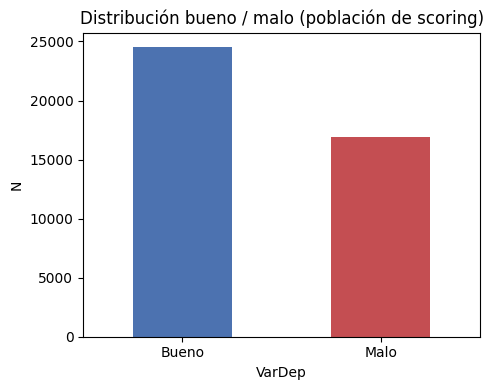

In [69]:
# Poblacion de scoring y tasa de malos
pob = info[info["VarDep"].isin([0, 1])]
print("Población total:           ", len(info))
print("Población de scoring (0/1):", len(pob),
      f"({len(pob) / len(info) * 100:.1f}%)")
print("Tasa de malos:             ", round(pob["VarDep"].mean(), 4))

plt.figure(figsize=(5, 4))
pob["VarDep"].map({0: "Bueno", 1: "Malo"}).value_counts().plot.bar(
    color=["#4c72b0", "#c44e52"])
plt.title("Distribución bueno / malo (población de scoring)")
plt.ylabel("N")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Calidad de datos

En credit scoring los **nulos** suelen ser informativos (cliente sin historial de
buró) y se tratan como un grupo aparte en el binning, no se imputan a ciegas.

In [70]:
# %% Tabla de calidad de datos
vars_eda = VARS_NUM + VARS_CAT + ["VarDep"]
calidad = pd.DataFrame({
    "tipo": info[vars_eda].dtypes.astype(str),
    "n_nulos": info[vars_eda].isna().sum(),
    "pct_nulos": (info[vars_eda].isna().mean() * 100).round(2),
    "n_unicos": info[vars_eda].nunique(),
})
calidad

,tipo,n_nulos,pct_nulos,n_unicos
edad,float64,191,0.24,76
INGRESOS,float64,0,0.00,28670
CARGAS,int64,0,0.00,12
ANTIG_LABORAL,int64,0,0.00,642
score419,float64,1,0.00,948
MAX_DVEN_SCE_6M,int64,0,0.00,3691
numOpsVencidas101,float64,1,0.00,25
NOPE_VENC_OP_3M,int64,0,0.00,27
DEUDA_TOTAL_SCE_12M,float64,0,0.00,78969
SALDO_PROMEDIO_AHORRO,float64,0,0.00,19849


## 3. Análisis univariado

In [71]:
# Estadisticos descriptivos - variables numericas
info[VARS_NUM].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,79400.0,42.859093,13.228207,15.0,32.000,41.00,52.000,1.080000e+02
INGRESOS,79591.0,2109.587665,7057.506012,0.0,714.000,1290.00,2365.000,1.218555e+06
CARGAS,79591.0,0.766142,0.985306,0.0,0.000,0.00,1.000,3.200000e+01
ANTIG_LABORAL,79591.0,106.306856,95.726929,-26.0,41.000,80.00,144.000,1.472000e+03
score419,79590.0,610.578163,354.516219,0.0,313.000,735.00,918.000,9.780000e+02
MAX_DVEN_SCE_6M,79591.0,313.061992,808.464215,0.0,0.000,7.00,180.000,1.344400e+04
numOpsVencidas101,79590.0,0.599435,1.292775,0.0,0.000,0.00,1.000,4.300000e+01
NOPE_VENC_OP_3M,79591.0,0.614077,1.302418,0.0,0.000,0.00,1.000,4.500000e+01
DEUDA_TOTAL_SCE_12M,79591.0,228479.045514,672959.980481,0.0,39553.435,104317.79,252467.845,1.186295e+08
SALDO_PROMEDIO_AHORRO,79591.0,435.854705,2885.422140,0.0,0.000,4.03,28.105,9.799166e+04


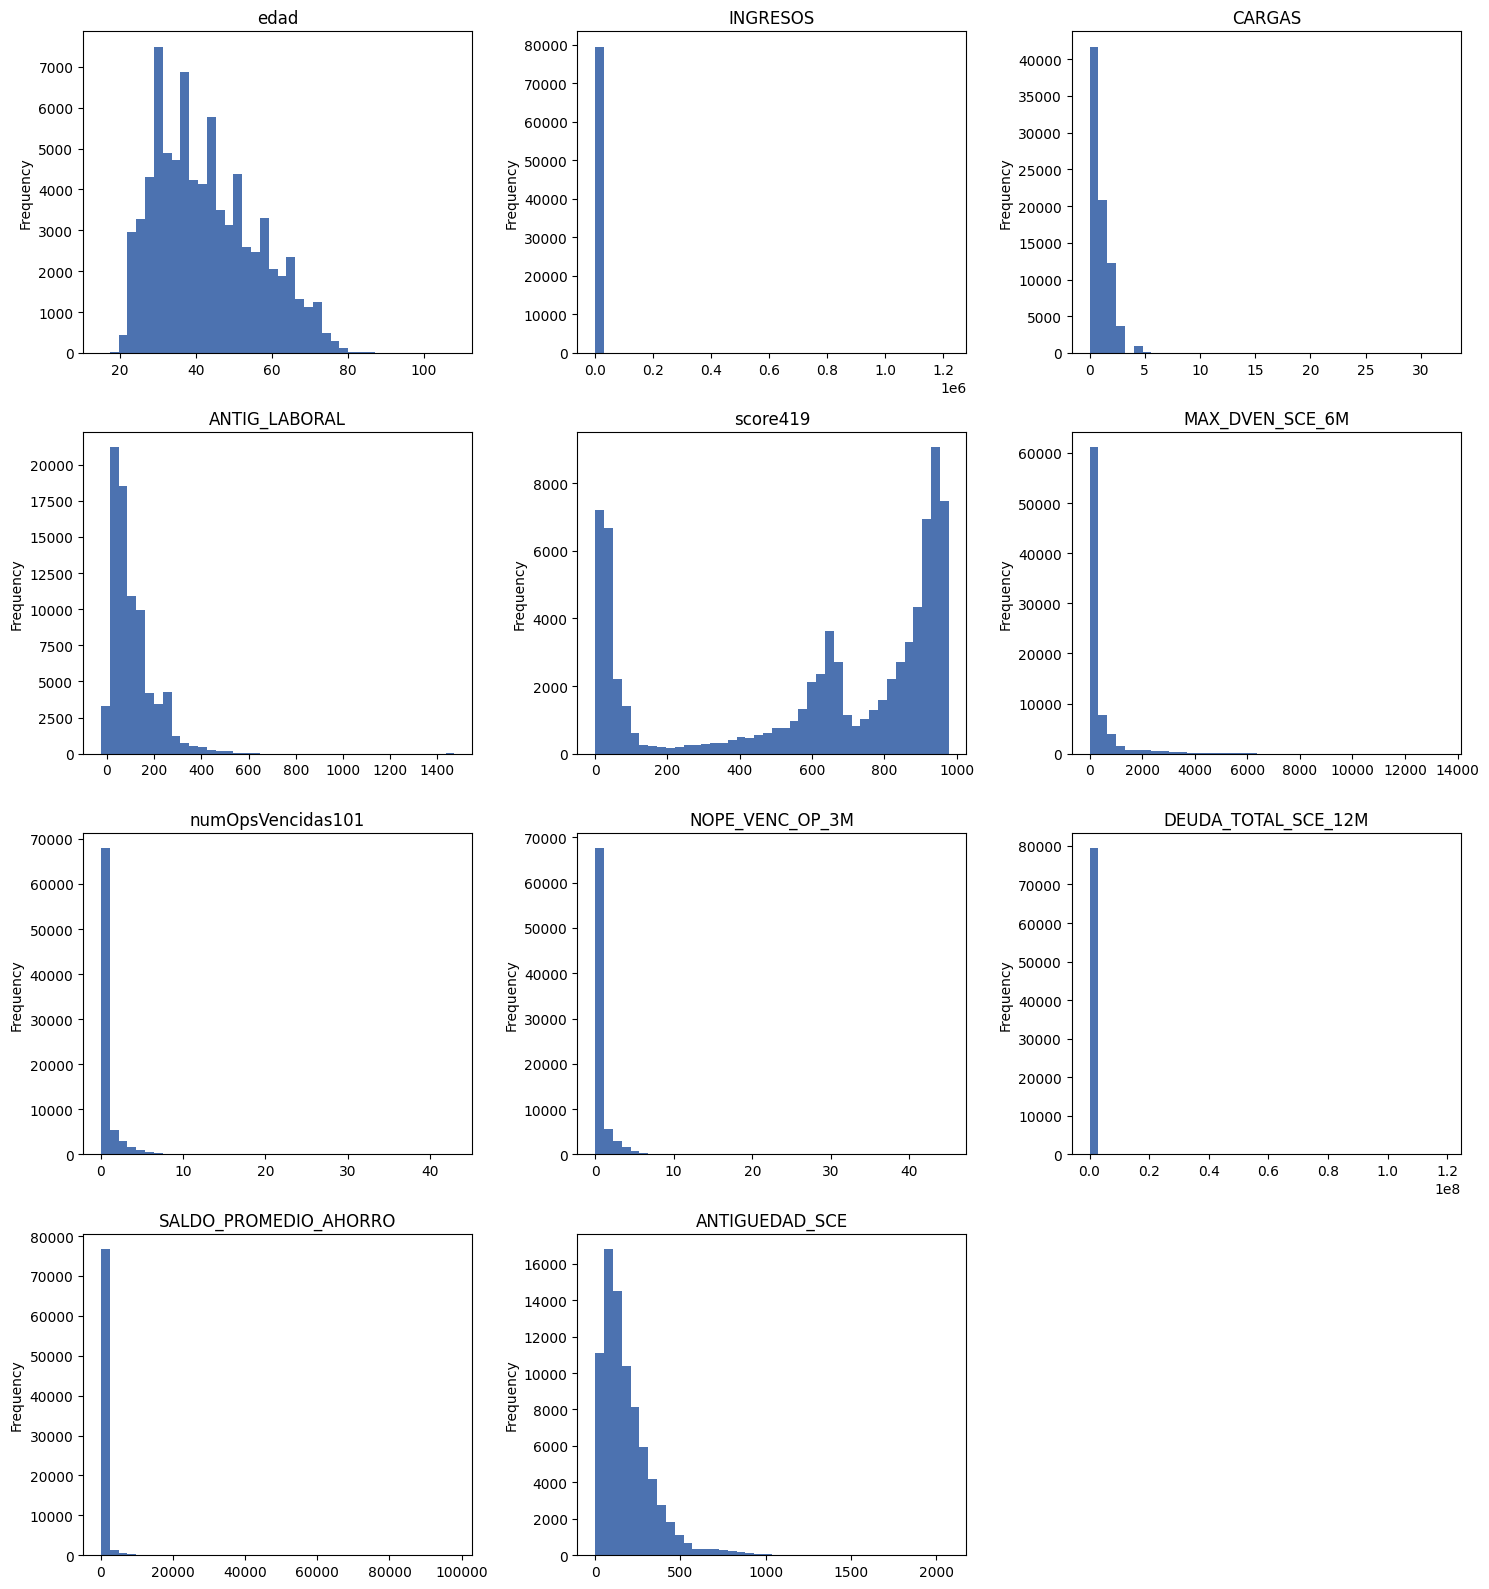

In [72]:
#  Histogramas - variables numericas
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, v in zip(axes.flat, VARS_NUM):
    info[v].plot.hist(bins=40, ax=ax, color="#4c72b0")
    ax.set_title(v)
for ax in axes.flat[len(VARS_NUM):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

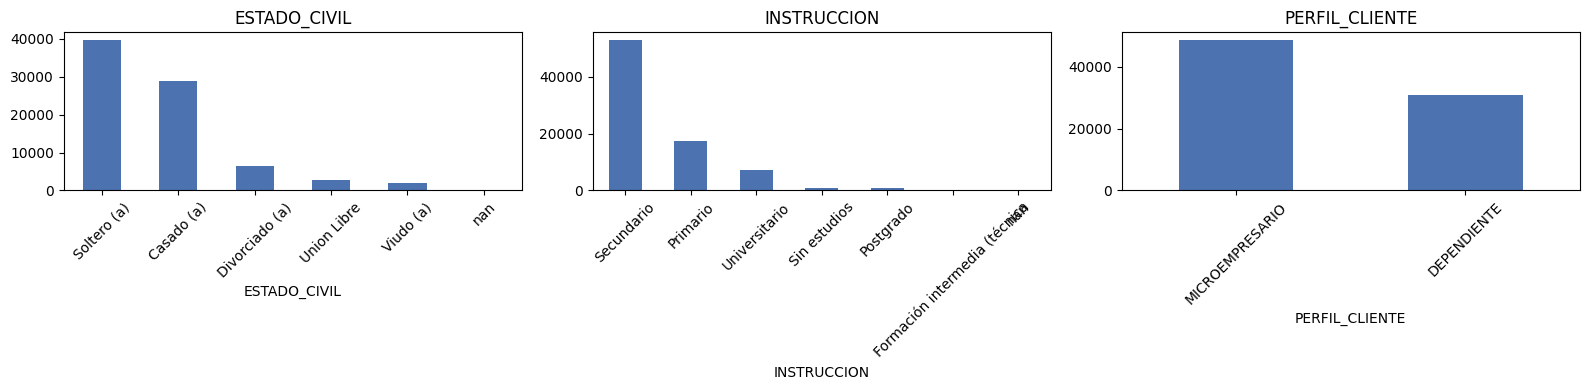

In [73]:
# Distribucion - variables categoricas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, v in zip(axes, VARS_CAT):
    info[v].value_counts(dropna=False).plot.bar(ax=ax, color="#4c72b0")
    ax.set_title(v)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Análisis bivariado con el target

El núcleo del EDA en scoring: cómo varía la **tasa de malos** según cada variable.
Una variable es útil si discrimina riesgo y, idealmente, de forma **monótona**.

> ### 🤖 Asistencia de IA — *prompt del paso*

"Quiero visualizar la relación entre mis variables predictoras y la variable objetivo binaria `VarDep` (0 = bueno, 1 = malo), mostrando no solo la tasa de malos sino también la distribución relativa de buenos y malos para evaluar estabilidad, representatividad y capacidad discriminatoria.

1. Para variables numéricas (`VARS_NUM`):
- Dividir cada variable en deciles usando `pd.qcut`.
- Graficar barras apiladas con la proporción de buenos y malos dentro de cada decil.
- Añadir una línea horizontal punteada con la tasa global de malos.
- Mostrar todos los gráficos organizados en una grilla ordenada.

2. Para variables categóricas (`VARS_CAT`):
- Calcular la proporción de buenos y malos por categoría.
- Ordenar las categorías según la tasa de malos.
- Graficar barras apiladas con la distribución relativa de buenos y malos.
- Añadir una línea horizontal punteada con la tasa global.


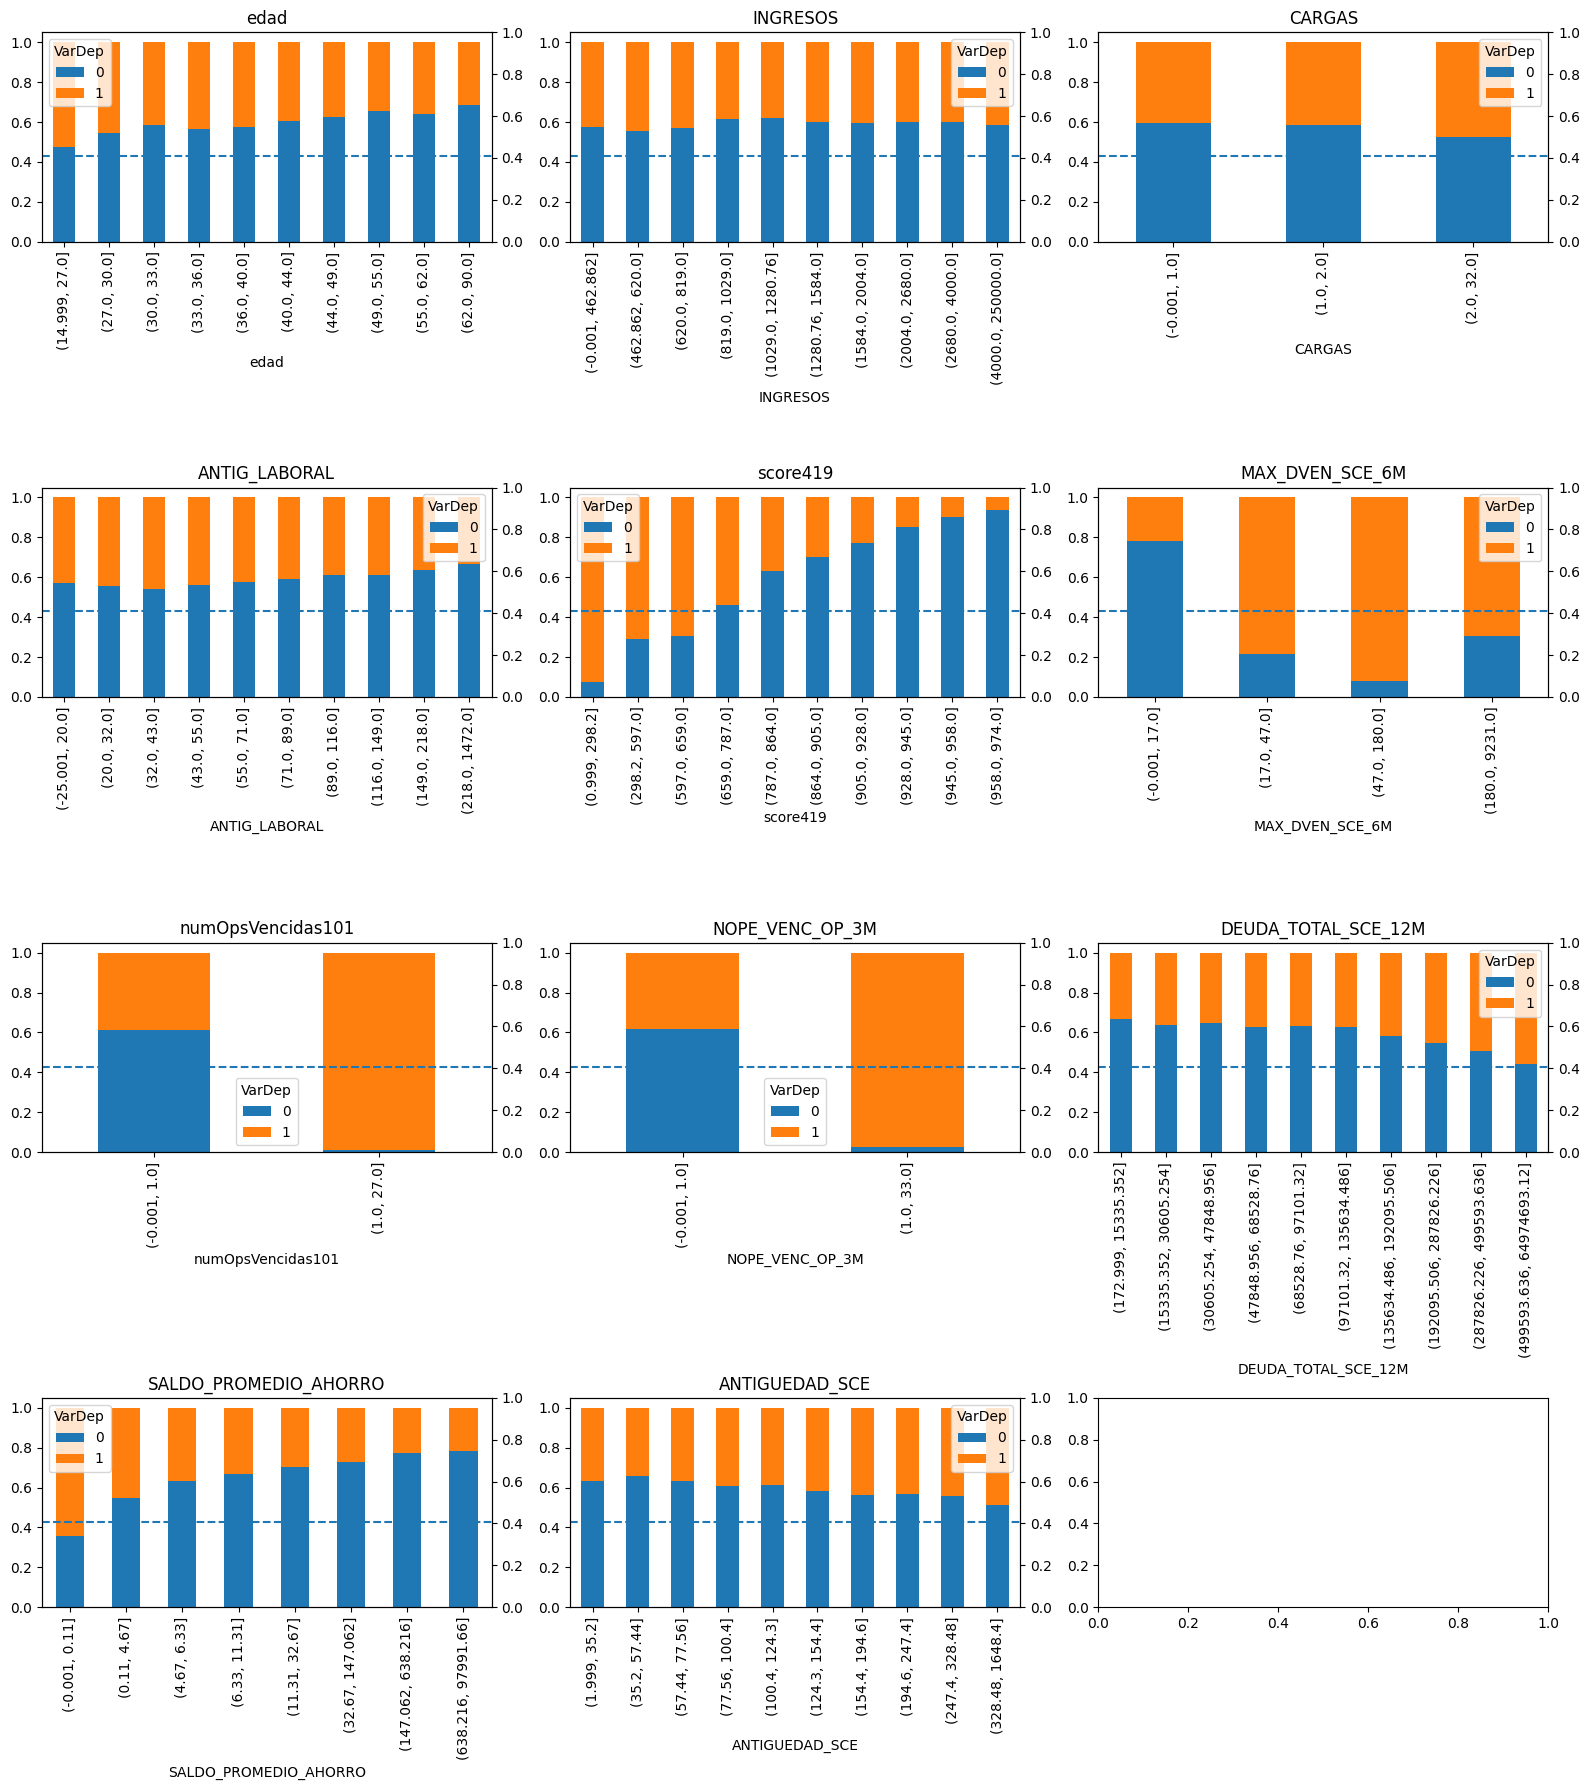

In [74]:
fig, axes = plt.subplots(4, 3, figsize=(16,18))

for ax, v in zip(axes.flat, VARS_NUM):

    grp = pd.qcut(pob[v], 10, duplicates='drop')

    tab = (
        pob.groupby([grp, 'VarDep'], observed=True)
        .size()
        .unstack(fill_value=0)
    )

    # proporciones por decil
    prop = tab.div(tab.sum(axis=1), axis=0)

    prop.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    # tasa de malos

    ax2 = ax.twinx()
    ax2.axhline(
        pob['VarDep'].mean(),
        linestyle='--'
    )

    ax.set_title(v)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

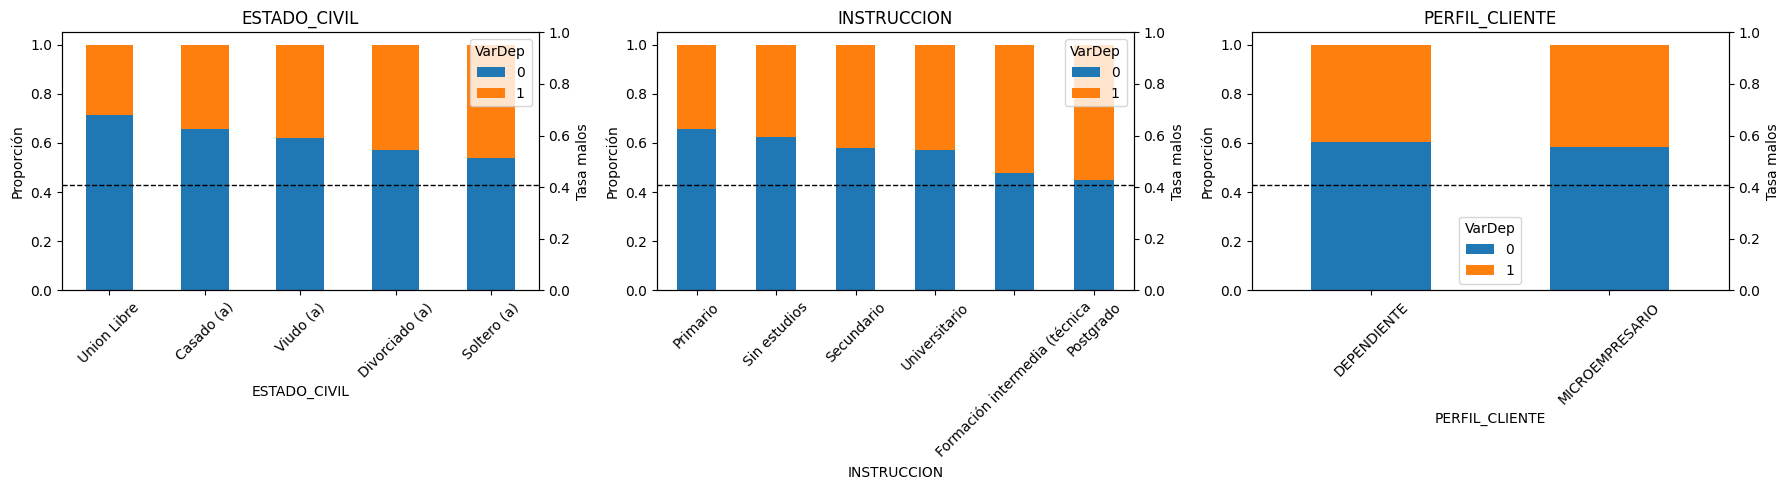

In [75]:
fig, axes = plt.subplots(1, len(VARS_CAT), figsize=(18, 5))

if len(VARS_CAT) == 1:
    axes = [axes]

for ax, v in zip(axes, VARS_CAT):

    tab = (
        pob.groupby([v, "VarDep"], observed=True)
        .size()
        .unstack(fill_value=0)
    )

    # proporciones dentro de cada categoría
    prop = tab.div(tab.sum(axis=1), axis=0)

    # ordenar por tasa de malos
    prop = prop.sort_values(by=1)

    # barras apiladas
    prop.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    # línea tasa de malos
    ax2 = ax.twinx()


    # tasa global
    ax2.axhline(
        pob["VarDep"].mean(),
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"{v}")
    ax.set_ylabel("Proporción")
    ax2.set_ylabel("Tasa malos")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. WoE e Information Value

El **Weight of Evidence** (WoE) y el **Information Value** (IV) son la métrica estándar
de poder predictivo en credit scoring; además es una técnica *filter* — adelanta el
paso de Feature Selection.

- `WoE = ln( %buenos / %malos )` por grupo
- `IV = Σ (%buenos − %malos) · WoE`

Interpretación del IV: <0.02 inútil · 0.02–0.1 débil · 0.1–0.3 medio · 0.3–0.5 fuerte ·
>0.5 sospechosamente alto.

In [76]:
# %% Funcion WoE / IV
def woe_iv(var, bins=10):
    d = info.loc[info["VarDep"].isin([0, 1]), [var, "VarDep"]].copy()
    if var in VARS_CAT:
        d["grupo"] = d[var].astype("object").fillna("(NULO)")
    else:
        d["grupo"] = pd.qcut(d[var], bins, duplicates="drop")
        d["grupo"] = d["grupo"].cat.add_categories(["(NULO)"]).fillna("(NULO)")

    g = d.groupby("grupo", observed=True)["VarDep"].agg(N="count", malos="sum")
    g["buenos"] = g["N"] - g["malos"]
    g["tasa_malos"] = g["malos"] / g["N"]
    g["pct_malos"] = g["malos"] / g["malos"].sum()
    g["pct_buenos"] = g["buenos"] / g["buenos"].sum()
    eps = 1e-6
    g["WoE"] = np.log((g["pct_buenos"] + eps) / (g["pct_malos"] + eps))
    g["IV_parcial"] = (g["pct_buenos"] - g["pct_malos"]) * g["WoE"]
    return g, g["IV_parcial"].sum()

In [77]:
# Ranking de Information Value
def fuerza(iv):
    if iv < 0.02:
        return "inútil"
    if iv < 0.1:
        return "débil"
    if iv < 0.3:
        return "media"
    if iv < 0.5:
        return "fuerte"
    return "sospechosa (>0.5)"

filas = []
for v in VARS_NUM + VARS_CAT:
    _, iv = woe_iv(v)
    filas.append((v, iv))

iv_rank = pd.DataFrame(filas, columns=["variable", "IV"]).sort_values("IV", ascending=False)
iv_rank["poder_predictivo"] = iv_rank["IV"].apply(fuerza)
iv_rank.reset_index(drop=True)

,variable,IV,poder_predictivo
0,MAX_DVEN_SCE_6M,1.781263,sospechosa (>0.5)
1,score419,1.746139,sospechosa (>0.5)
2,SALDO_PROMEDIO_AHORRO,0.487276,fuerte
3,numOpsVencidas101,0.390956,fuerte
4,NOPE_VENC_OP_3M,0.378486,fuerte
5,DEUDA_TOTAL_SCE_12M,0.079963,débil
6,ESTADO_CIVIL,0.064646,débil
7,edad,0.061976,débil
8,ANTIGUEDAD_SCE,0.029183,débil
9,INSTRUCCION,0.022931,débil


In [78]:
# Detalle WoE de la variable mas predictiva
top_var = iv_rank.iloc[0]["variable"]
print("Variable con mayor IV:", top_var)
g, iv = woe_iv(top_var)
print("IV =", round(iv, 4))
g.round(4)

Variable con mayor IV: MAX_DVEN_SCE_6M
IV = 1.7813


,N,malos,buenos,tasa_malos,pct_malos,pct_buenos,WoE,IV_parcial
grupo,,,,,,,,
"(-0.001, 17.0]",29107,6421,22686,0.2206,0.3803,0.9257,0.8897,0.4853
"(17.0, 47.0]",4032,3164,868,0.7847,0.1874,0.0354,-1.6659,0.2531
"(47.0, 180.0]",6978,6412,566,0.9189,0.3797,0.0231,-2.7998,0.9985
"(180.0, 9231.0]",1276,889,387,0.6967,0.0526,0.0158,-1.2041,0.0444


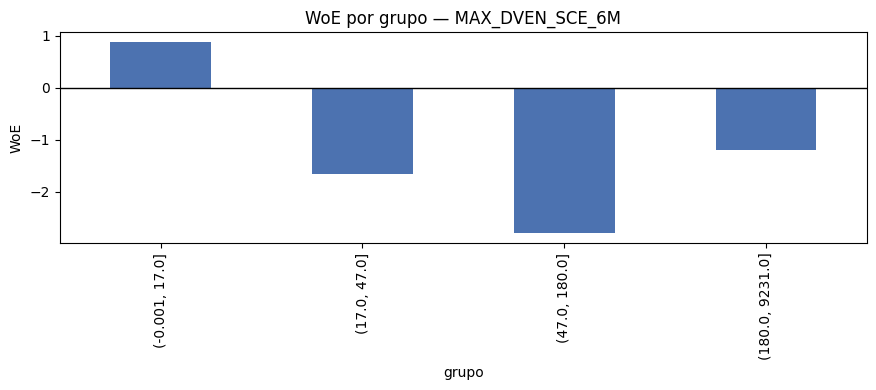

In [79]:
# %% Grafico WoE de la variable mas predictiva
plt.figure(figsize=(9, 4))
g["WoE"].plot.bar(color="#4c72b0")
plt.axhline(0, color="black", lw=1)
plt.title(f"WoE por grupo — {top_var}")
plt.ylabel("WoE")
plt.tight_layout()
plt.show()

## 6. Estabilidad temporal

Un buen modelo de scoring debe ser estable en el tiempo. Se revisa la tasa de malos
por cohorte (`FECHA_CORTE`) y el **PSI** (Population Stability Index) de una variable
clave entre cohortes.

                N  tasa_malos
FECHA_CORTE                  
2021-09-30   7334    0.382465
2021-12-31   7549    0.376739
2022-03-31   8055    0.399255
2022-06-30   8758    0.424412
2022-09-30   9697    0.443849


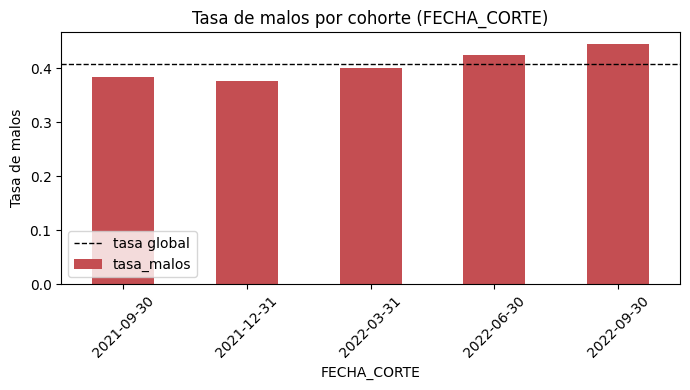

In [80]:
# Tasa de malos por cohorte
est = (pob.groupby("FECHA_CORTE")["VarDep"]
          .agg(N="count", tasa_malos="mean"))
print(est)

est_plot = est.copy()
est_plot.index = est_plot.index.astype(str)   # evita el error de fecha en el bar plot

plt.figure(figsize=(7, 4))
est_plot["tasa_malos"].plot.bar(color="#c44e52")
plt.axhline(pob["VarDep"].mean(), color="black", ls="--", lw=1, label="tasa global")
plt.title("Tasa de malos por cohorte (FECHA_CORTE)")
plt.ylabel("Tasa de malos")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
# Media de variables clave por cohorte
info.groupby("FECHA_CORTE")[VARS_NUM].mean().T.round(2)

FECHA_CORTE,2021-09-30,2021-12-31,2022-03-31,2022-06-30,2022-09-30
edad,43.75,43.50,43.09,42.46,41.82
INGRESOS,2101.43,2105.72,2157.58,2057.03,2126.66
CARGAS,0.78,0.78,0.77,0.76,0.75
ANTIG_LABORAL,107.37,108.89,106.37,105.34,104.24
score419,607.77,611.31,611.92,610.42,611.19
MAX_DVEN_SCE_6M,316.86,329.28,308.57,315.75,298.32
numOpsVencidas101,0.58,0.60,0.61,0.62,0.59
NOPE_VENC_OP_3M,0.63,0.62,0.61,0.60,0.61
DEUDA_TOTAL_SCE_12M,200942.49,212464.91,226614.05,241669.54,252497.91
SALDO_PROMEDIO_AHORRO,414.51,420.39,456.56,471.97,413.77


In [82]:
# PSI de score419 entre cohortes
def psi(base, actual, bins=10):
    base = pd.Series(base).dropna()
    actual = pd.Series(actual).dropna()
    cortes = np.unique(np.quantile(base, np.linspace(0, 1, bins + 1)))
    e = pd.cut(base, cortes, include_lowest=True).value_counts(normalize=True).sort_index()
    a = pd.cut(actual, cortes, include_lowest=True).value_counts(normalize=True).sort_index()
    e, a = e.align(a, fill_value=0)
    e = e.replace(0, 1e-6)
    a = a.replace(0, 1e-6)
    return float(((a - e) * np.log(a / e)).sum())

cohortes = sorted(info["FECHA_CORTE"].unique())
base = info.loc[info["FECHA_CORTE"] == cohortes[0], "score419"]
print("PSI de score419 (referencia = cohorte", str(cohortes[0])[:10], "):")
print("Interpretación: <0.1 estable · 0.1-0.25 cambio moderado · >0.25 cambio fuerte\n")
for ch in cohortes[1:]:
    act = info.loc[info["FECHA_CORTE"] == ch, "score419"]
    print(f"  {str(ch)[:10]}:  PSI = {psi(base, act):.4f}")

PSI de score419 (referencia = cohorte 2021-09-30 ):
Interpretación: <0.1 estable · 0.1-0.25 cambio moderado · >0.25 cambio fuerte

  2021-12-31:  PSI = 0.0050
  2022-03-31:  PSI = 0.0080
  2022-06-30:  PSI = 0.0164
  2022-09-30:  PSI = 0.0295


## 7. Correlaciones y outliers

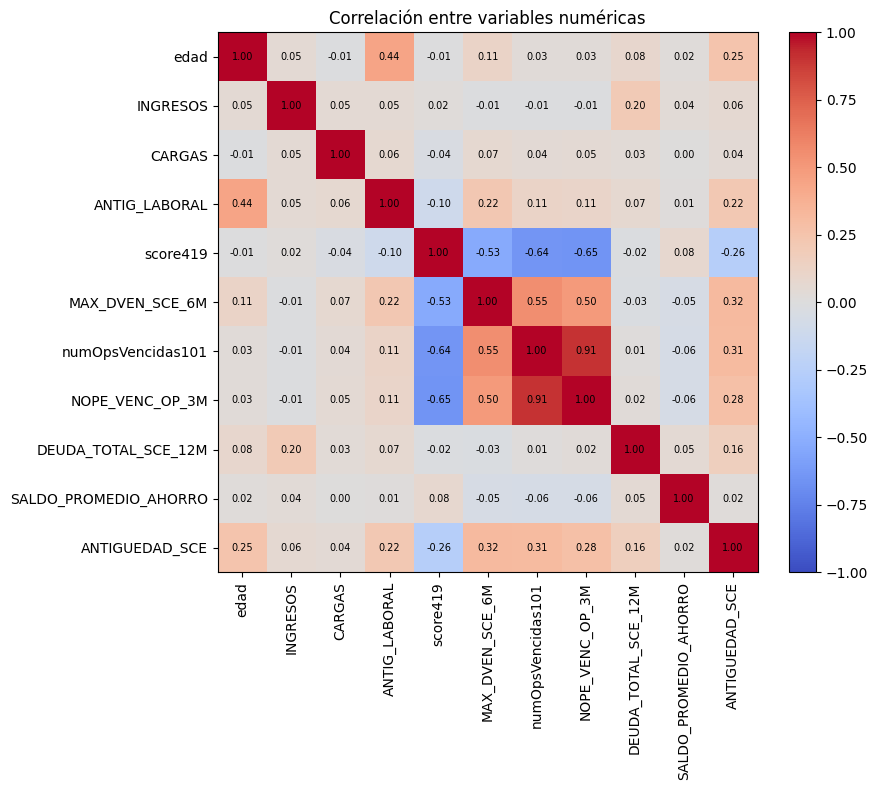

In [83]:
# Matriz de correlacion - variables numericas
corr_eda = info[VARS_NUM].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr_eda, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(VARS_NUM)))
ax.set_xticklabels(VARS_NUM, rotation=90)
ax.set_yticks(range(len(VARS_NUM)))
ax.set_yticklabels(VARS_NUM)
for i in range(len(VARS_NUM)):
    for j in range(len(VARS_NUM)):
        ax.text(j, i, f"{corr_eda.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, fraction=0.046)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

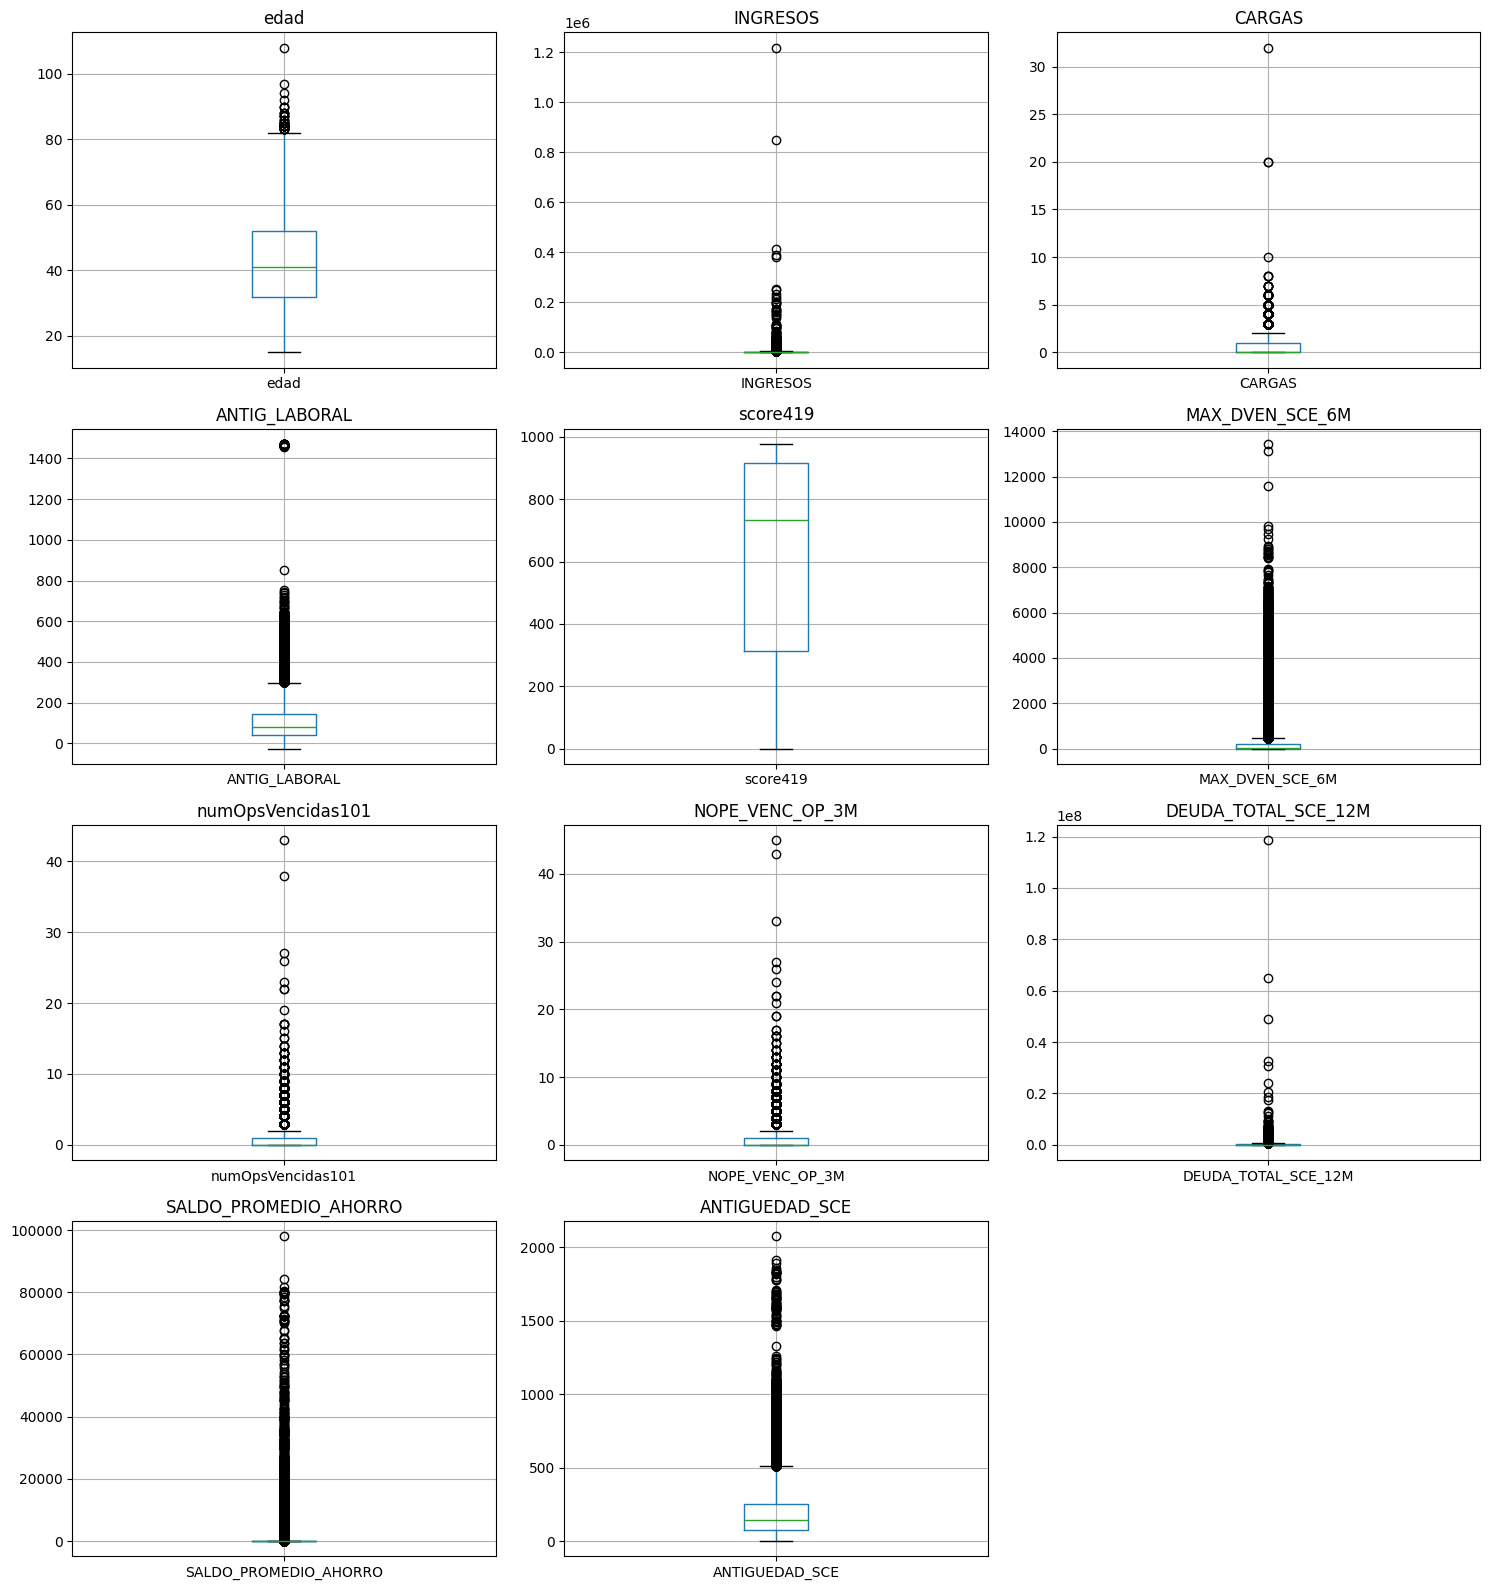

In [84]:
# Boxplots para deteccion de outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, v in zip(axes.flat, VARS_NUM):
    info.boxplot(column=v, ax=ax)
    ax.set_title(v)
for ax in axes.flat[len(VARS_NUM):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusiones del EDA

- **Población.** De 79.591 registros, la **población de scoring** (`VarDep` 0/1) es de
  **41.393 (52%)**; el 48% restante son exclusiones de diseño: indeterminados (24%),
  vencidos >180 d (22%), sin desempeño (1,2%) y no bancarizados (0,9%). La **tasa de
  malos es 40,8%** — una base relativamente balanceada.
- **Calidad.** Las 14 variables analizadas casi no tienen nulos (`edad` 0,24%;
  `score419` 1 registro) → no se requiere imputación agresiva.
- **Poder predictivo (IV).** El riesgo lo explica el **comportamiento de buró**, no el
  perfil socioeconómico: `MAX_DVEN_SCE_6M` (IV ≈ 1,78) y `score419` (IV ≈ 1,75)
  dominan, seguidas de `SALDO_PROMEDIO_AHORRO` (0,49), `numOpsVencidas101` (0,39) y
  `NOPE_VENC_OP_3M` (0,38). Las socioeconómicas son débiles (`edad` 0,06,
  `INGRESOS` 0,006).
- **Señal de alerta.** Los IV de mora y score son **> 0,5 (sospechosos)**, incluso
  ≈ 1,7: indican predictores casi deterministas → hay que verificar que no exista
  fuga (mora pasada que casi coincide con la mora futura).
- **Estabilidad temporal.** La tasa de malos sube de 38,2% (2021-09) a 44,4% (2022-09)
  — leve deterioro. El **PSI de `score419` es < 0,03** en todas las cohortes → las
  distribuciones son muy estables, lo que valida usar la cohorte reciente como Test OOT.
- **Outliers.** Hay colas largas (`INGRESOS`, `DEUDA_TOTAL`, mora) → se atienden con el
  capeo `_c` y el binning.

# Feature Extraction

Este paso aplica a datos **no estructurados** (texto, imágenes), donde hay que
*extraer* características. El dataset de este proyecto es **tabular estructurado**
(variables de buró y de perfil del cliente), por lo que *Feature Extraction* **no
aplica**. El trabajo de ingeniería de variables relevante aquí es la **discretización**
(siguiente sección) y la **selección por Information Value**.

## Partición Desarrollo / Test OOT

Solo **dos bloques**: `DEV` (desarrollo, cohortes 2021-09 a 2022-06) y `TEST_OOT`
(cohorte más reciente, 2022-09). No se separa un `VAL` fijo: la validación la hace
el **k-fold cross-validation** dentro de `DEV` (paso 5), agrupado por cliente.

In [85]:
import numpy as np
import pandas as pd

# Cohorte OOT = la más reciente; el resto es desarrollo (DEV)
fecha_oot = [pd.Timestamp("2022-09-30")]
es_oot = info["FECHA_CORTE"].isin(fecha_oot)

info["MUESTRA"] = np.where(es_oot, "TEST_OOT", "DEV")

# Verificar tamaños y tasa de malos (solo VarDep 0/1)
chk = info[info["VarDep"].isin([0, 1])]
resumen = chk.groupby("MUESTRA").agg(
    N=("VarDep", "size"),
    tasa_malos=("VarDep", "mean"),
)
resumen["pct"] = resumen["N"] / resumen["N"].sum()
print(resumen)

# distribución por cohorte
pd.crosstab(info["FECHA_CORTE"], info["MUESTRA"])

/var/folders/v6/d_4300n96432y2g47c2hlw640000gn/T/ipykernel_1721/721508103.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  info["MUESTRA"] = np.where(es_oot, "TEST_OOT", "DEV")


              N  tasa_malos       pct
MUESTRA                              
DEV       31696    0.396959  0.765733
TEST_OOT   9697    0.443849  0.234267


MUESTRA,DEV,TEST_OOT
FECHA_CORTE,,
2021-09-30,14304,0
2021-12-31,14665,0
2022-03-31,15630,0
2022-06-30,16862,0
2022-09-30,0,18130


# Creación de variables — Discretización

Antes de modelar se transforman las variables crudas en **predictores discretizados**:

1. Los árboles (cortes) se ajustan **solo con `DEV`** — nunca ven `TEST_OOT`.
2. Las reglas ajustadas se aplican a `DEV`.
3. `TEST_OOT` se deja intacto; se discretizará tras el feature selection.

Por variable se crean `bin_<var>` (bin), `prbm_<var>` (P malo, estimada en DEV) y
`prbb_<var>` = 1 − `prbm_<var>`.

## Separar muestra de desarrollo

Se trabaja `DEV`. `TEST_OOT` **no se toca** todavía: se discretizará después del
feature selection.

In [86]:
# %% Muestra de desarrollo (TEST_OOT se deja para despues)
dev = info[info["MUESTRA"] == "DEV"].copy()
print("DEV:", dev.shape)

DEV: (61461, 2507)


## Framework de binning con árboles de decisión

`fit_arbol` ajusta un `DecisionTreeClassifier` **solo con DEV** (`VarDep` 0/1) sobre
1 o 2 columnas fuente. `aplicar_arbol` transforma cualquier muestra con la regla ya
ajustada: los cortes salen del árbol y `prbm` = `predict_proba` (proporción de malos
por hoja, calculada en DEV). Los registros con nulos forman un bin aparte (`-1`)
con la tasa de malos de los nulos en DEV.

In [87]:
# Funciones de binning (fit en DEV / apply en cualquier muestra)
def fit_arbol(cols, max_leaf_nodes=5, min_frac=0.05):
    # Ajusta un arbol SOLO con DEV (VarDep 0/1). 'cols' = 1 o 2 columnas fuente.
    base = dev[dev["VarDep"].isin([0, 1])]
    completos = base[cols].notna().all(axis=1)
    d = base.loc[completos]
    tree = DecisionTreeClassifier(
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_frac,
        random_state=13579,
    )
    tree.fit(d[cols], d["VarDep"])
    # tasa de malos de los registros con algun nulo (bin "missing")
    faltantes = base.loc[~completos, "VarDep"]
    p_na = faltantes.mean() if len(faltantes) else base["VarDep"].mean()
    return {"cols": cols, "tree": tree, "p_na": float(p_na),
            "tasa_global": float(base["VarDep"].mean())}


def aplicar_arbol(df, regla):
    # Aplica una regla ya ajustada: devuelve (bin, prbm). bin = -1 para nulos.
    cols = regla["cols"]
    completos = df[cols].notna().all(axis=1)
    bin_ = pd.Series(-1, index=df.index, dtype="int64")
    prbm = pd.Series(regla["p_na"], index=df.index, dtype="float64")
    if completos.any():
        X = df.loc[completos, cols]
        bin_.loc[completos] = regla["tree"].apply(X)
        prbm.loc[completos] = regla["tree"].predict_proba(X)[:, 1]
    prbm = prbm.fillna(regla["tasa_global"])
    return bin_, prbm


def cortes(nombre):
    # Umbrales internos aprendidos por el arbol
    t = reglas[nombre]["tree"].tree_
    es_hoja = t.children_left == t.children_right
    return sorted(np.round(t.threshold[~es_hoja], 4).tolist())

In [88]:
# %% Variables a discretizar (nombre -> columnas fuente)
VARIABLES = {
    # univariadas
    "MAX_DVEN_SCE_6M":                 ["MAX_DVEN_SCE_6M"],
    "PROM_VEN_SCE_6M":                 ["PROM_VEN_SCE_6M"],
    "maySalVen24M269":                 ["maySalVen24M269"],
    "NENT_VEN_SCE_24M":                ["NENT_VEN_SCE_24M"],
    "maySalVenD3M227":                 ["maySalVenD3M227"],
    "califHisTitularY361":             ["califHisTitularY361"],
    "NOPE_XVEN_OP_3M":                 ["NOPE_XVEN_OP_3M"],
    "NOPE_APERT_SCE_OP_3M":            ["NOPE_APERT_SCE_OP_3M"],
    "PROM_NDI_SCE_36M":                ["PROM_NDI_SCE_36M"],
    "NOPE_VENC_OP_3M":                 ["NOPE_VENC_OP_3M"],
    # bivariadas (el arbol modela la interaccion)
    "MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO": ["MAX_DVEN_SCE_6M", "SALDO_PROMEDIO_AHORRO"],
    "NOPE_VENC_OP_12_y_INGRESOS":              ["NOPE_VENC_OP_12M", "INGRESOS"],
    "edad_y_INGRESOS":                         ["edad", "INGRESOS"],
    "NOPE_NDI_OP_3MySalTotOpD383":             ["NOPE_NDI_OP_3M", "SalTotOpD383"],
}

# Ajuste de todas las reglas SOLO con DEV
reglas = {nombre: fit_arbol(cols) for nombre, cols in VARIABLES.items()}

for nombre, r in reglas.items():
    print(f"{nombre:42s} cols={r['cols']}  bins={r['tree'].get_n_leaves()}  "
          f"cortes={cortes(nombre)}")

MAX_DVEN_SCE_6M                            cols=['MAX_DVEN_SCE_6M']  bins=5  cortes=[1.5, 14.5, 30.5, 56.5]
PROM_VEN_SCE_6M                            cols=['PROM_VEN_SCE_6M']  bins=4  cortes=[0.305, 25.755, 130.86]
maySalVen24M269                            cols=['maySalVen24M269']  bins=5  cortes=[0.07, 68.77, 162.77, 528.46]
NENT_VEN_SCE_24M                           cols=['NENT_VEN_SCE_24M']  bins=4  cortes=[0.5, 1.5, 2.5]
maySalVenD3M227                            cols=['maySalVenD3M227']  bins=4  cortes=[0.005, 69.895, 227.97]
califHisTitularY361                        cols=['califHisTitularY361']  bins=5  cortes=[0.5, 1.5, 2.5, 4.5]
NOPE_XVEN_OP_3M                            cols=['NOPE_XVEN_OP_3M']  bins=5  cortes=[1.5, 2.5, 3.5, 6.5]
NOPE_APERT_SCE_OP_3M                       cols=['NOPE_APERT_SCE_OP_3M']  bins=4  cortes=[0.5, 1.5, 2.5]
PROM_NDI_SCE_36M                           cols=['PROM_NDI_SCE_36M']  bins=4  cortes=[5.955, 144.895, 503.45]
NOPE_VENC_OP_3M                 

## Construcción de features

In [89]:
# Funcion que construye TODAS las variables sobre una muestra dada
def construir_features(df):
    df = df.copy()

    # --- Binning con arboles (reglas ajustadas en DEV) ---
    for nombre, regla in reglas.items():
        b, prbm = aplicar_arbol(df, regla)
        df[f"bin_{nombre}"] = b
        df[f"prbm_{nombre}"] = prbm
        df[f"prbb_{nombre}"] = 1 - prbm

    # --- Variables dummy (deterministicas, fila a fila) ---
    df["d_numOpsVencidas3M102_cast"] = np.where(df["numOpsVencidas3M102"] > 0, 1, 0)
    df["d_numOpsVencidas3M102_prem"] = np.where(df["numOpsVencidas3M102"] == 0, 1, 0)
    df["d_numOpsVencidas101_cast"] = np.where(df["numOpsVencidas101"] > 0, 1, 0)
    df["d_numOpsVencidas101_prem"] = np.where(df["numOpsVencidas101"] == 0, 1, 0)
    df["d_numOpeCarteraCastigadaTitular376_cast"] = np.where(
        df["numOpeCarteraCastigadaTitular376"] > 0, 1, 0)
    df["d_numOpeCarteraCastigadaTitular376_prem"] = np.where(
        df["numOpeCarteraCastigadaTitular376"] == 0, 1, 0)
    df["d_peorNivelRiesgoValorOpBanCooComD415_prem"] = np.where(
        df["peorNivelRiesgoValorOpBanCooComD415"] <= 1, 1, 0)
    df["d_peorNivelRiesgoValorOpBanCooComD415_cast"] = np.where(
        df["peorNivelRiesgoValorOpBanCooComD415"] > 1, 1, 0)
    df["d_NOPE_NDI_OP_3M_cast"] = np.where(df["NOPE_NDI_OP_3M"] > 0, 1, 0)

    # --- Capeo de atipicos (umbrales fijos) ---
    df["califHisTitularV360_c"] = np.where(df["califHisTitularV360"] > 23, 23, df["califHisTitularV360"])
    df["MAX_DVEN_SF_OP_12M_c"] = np.where(df["MAX_DVEN_SF_OP_12M"] > 270, 270, df["MAX_DVEN_SF_OP_12M"])
    df["numOpsVig092_c"] = np.where(df["numOpsVig092"] > 59, 59, df["numOpsVig092"])
    df["MAX_DVEN_SCE_36M_c"] = np.where(df["MAX_DVEN_SCE_36M"] > 1583.54, 1583.54, df["MAX_DVEN_SCE_36M"])
    df["MAX_DVEN_SCE_6M_c"] = np.where(df["MAX_DVEN_SCE_6M"] > 360, 360, df["MAX_DVEN_SCE_6M"])
    df["SALDO_PROMEDIO_AHORRO_c"] = np.where(
        df["SALDO_PROMEDIO_AHORRO"] > 10500.9854, 10500.9854, df["SALDO_PROMEDIO_AHORRO"])
    df["NOPE_APERT_SCE_OP_24M_c"] = np.where(
        df["NOPE_APERT_SCE_OP_24M"] > 25, 25, df["NOPE_APERT_SCE_OP_24M"])
    df["NOPE_NDI_OP_24M_c"] = np.where(df["NOPE_NDI_OP_24M"] > 2, 2, df["NOPE_NDI_OP_24M"])
    df["SalTotOpD383_c"] = np.where(df["SalTotOpD383"] > 141419.8156, 2, df["SalTotOpD383"])
    df["NOPE_APERT_SF_OP_6M_c"] = np.where(df["NOPE_APERT_SF_OP_6M"] > 7, 7, df["NOPE_APERT_SF_OP_6M"])
    df["NOPE_APERT_SCE_OP_12M_c"] = np.where(
        df["NOPE_APERT_SCE_OP_12M"] > 15, 15, df["NOPE_APERT_SCE_OP_12M"])
    df["salOpVen014_c"] = np.where(df["salOpVen014"] > 8723.8756, 8723.8756, df["salOpVen014"])
    df["DEUDA_TOTAL_SCE_12M_c"] = np.where(
        df["DEUDA_TOTAL_SCE_12M"] > 1745712.081, 1745712.081, df["DEUDA_TOTAL_SCE_12M"])
    df["NOPE_REFIN_OP_12M_c"] = np.where(df["NOPE_REFIN_OP_12M"] >= 2, 2, df["NOPE_REFIN_OP_12M"])
    df["numOpsVencidas101_c"] = np.where(df["numOpsVencidas101"] >= 2, 2, df["numOpsVencidas101"])
    df["numOpsVencidas3M102_c"] = np.where(df["numOpsVencidas3M102"] >= 3, 3, df["numOpsVencidas3M102"])
    df["maySalVen24M269_c"] = np.where(
        df["maySalVen24M269"] >= 1881.4544, 1881.4544, df["maySalVen24M269"])

    return df.copy()   # defragmentar tras las inserciones

In [90]:
# Aplicar a DEV  (TEST_OOT se deja para despues del feature selection)
dev = construir_features(dev)
print("DEV:", dev.shape)

DEV: (61461, 2575)


## Diagnóstico de los bins en DEV

In [91]:
# Tasa de malos y N por bin (en DEV) — control de monotonia
def reporte_bin(nombre):
    tr = dev[dev["VarDep"].isin([0, 1])]
    g = tr.groupby(f"bin_{nombre}").agg(N=("VarDep", "size"),
                                        tasa_malos=("VarDep", "mean"))
    g["prbm"] = tr.groupby(f"bin_{nombre}")[f"prbm_{nombre}"].first()
    return g


for nombre in reglas:
    print("===", nombre, "| cortes:", cortes(nombre))
    display(reporte_bin(nombre))

=== MAX_DVEN_SCE_6M | cortes: [1.5, 14.5, 30.5, 56.5]


,N,tasa_malos,prbm
bin_MAX_DVEN_SCE_6M,,,
1,19910,0.162330,0.162330
5,1969,0.574911,0.574911
6,2433,0.720099,0.720099
7,1651,0.858268,0.858268
8,5733,0.880691,0.880691


=== PROM_VEN_SCE_6M | cortes: [0.305, 25.755, 130.86]


,N,tasa_malos,prbm
bin_PROM_VEN_SCE_6M,,,
1,25261,0.276869,0.276869
3,2031,0.790743,0.790743
5,2186,0.881519,0.881519
6,2218,0.926510,0.926510


=== maySalVen24M269 | cortes: [0.07, 68.77, 162.77, 528.46]


...

,N,tasa_malos,prbm
bin_NOPE_VENC_OP_12_y_INGRESOS,,,
3,4341,0.735314,0.735314
4,2526,0.889153,0.889153
5,6480,0.312191,0.312191
7,7345,0.261675,0.261675
8,11004,0.290712,0.290712


=== edad_y_INGRESOS | cortes: [25.5, 37.5, 47.5, 1429.98]


,N,tasa_malos,prbm
bin_edad_y_INGRESOS,,,
-1,95,0.631579,0.631579
3,1913,0.555672,0.555672
4,11461,0.429631,0.429631
5,7717,0.387845,0.387845
7,5040,0.315079,0.315079
8,5470,0.357221,0.357221


=== NOPE_NDI_OP_3MySalTotOpD383 | cortes: [0.5, 5386.29, 15385.6553, 62057.7598]


,N,tasa_malos,prbm
bin_NOPE_NDI_OP_3MySalTotOpD383,,,
2,1874,0.976521,0.976521
5,7897,0.414461,0.414461
6,1698,0.513545,0.513545
7,11123,0.309809,0.309809
8,9104,0.347210,0.347210


## Guardar reglas de binning

In [92]:
# Guardar las reglas ajustadas (arboles) para aplicarlas luego a TEST_OOT
with open("BDD/reglas_binning.pkl", "wb") as f:
    pickle.dump(reglas, f)
print("Reglas guardadas en BDD/reglas_binning.pkl")

Reglas guardadas en BDD/reglas_binning.pkl


## Pendiente: aplicar a TEST_OOT

Después del *feature selection*, se aplican las **mismas reglas** (ya ajustadas en
DEV) a la muestra OOT. No se ajusta nada nuevo:

```python
reglas = pickle.load(open("BDD/reglas_binning.pkl", "rb"))
test = info[info["MUESTRA"] == "TEST_OOT"].copy()
test = construir_features(test)
```

In [93]:
# Resumen de variables creadas (en DEV)
nuevas = [c for c in dev.columns
          if c.startswith(("bin_", "prbm_", "prbb_", "d_")) or c.endswith("_c")]
print(len(nuevas), "variables creadas:")
for c in sorted(nuevas):
    print(" -", c)

68 variables creadas:
 - DEUDA_TOTAL_SCE_12M_c
 - MAX_DVEN_SCE_36M_c
 - MAX_DVEN_SCE_6M_c
 - MAX_DVEN_SF_OP_12M_c
 - NOPE_APERT_SCE_OP_12M_c
 - NOPE_APERT_SCE_OP_24M_c
 - NOPE_APERT_SF_OP_6M_c
 - NOPE_NDI_OP_24M_c
 - NOPE_REFIN_OP_12M_c
 - SALDO_PROMEDIO_AHORRO_c
 - SalTotOpD383_c
 - bin_MAX_DVEN_SCE_6M
 - bin_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO
 - bin_NENT_VEN_SCE_24M
 - bin_NOPE_APERT_SCE_OP_3M
 - bin_NOPE_NDI_OP_3MySalTotOpD383
 - bin_NOPE_VENC_OP_12_y_INGRESOS
 - bin_NOPE_VENC_OP_3M
 - bin_NOPE_XVEN_OP_3M
 - bin_PROM_NDI_SCE_36M
 - bin_PROM_VEN_SCE_6M
 - bin_califHisTitularY361
 - bin_edad_y_INGRESOS
 - bin_maySalVen24M269
 - bin_maySalVenD3M227
 - califHisTitularV360_c
 - d_NOPE_NDI_OP_3M_cast
 - d_numOpeCarteraCastigadaTitular376_cast
 - d_numOpeCarteraCastigadaTitular376_prem
 - d_numOpsVencidas101_cast
 - d_numOpsVencidas101_prem
 - d_numOpsVencidas3M102_cast
 - d_numOpsVencidas3M102_prem
 - d_peorNivelRiesgoValorOpBanCooComD415_cast
 - d_peorNivelRiesgoValorOpBanCooComD415

# Feature Selection

Esquema **híbrido Filter + Wrapper**, todo estimado **solo con `DEV`** (sin ver
`TEST_OOT`):

0. **Validación de cobertura** — se escanea el IV de *todas* las variables crudas para
   confirmar que la lista de variables discretizadas no dejó fuera predictores fuertes.
1. **Filter — Information Value (IV):** descarta variables con IV < 0.02 y marca las de
   IV > 0.5 (posible fuga). Filtro univariado, rápido, estándar en scoring.
2. **Filter — Redundancia:** entre variables muy correlacionadas conserva la de mayor IV.
3. **Wrapper — RFECV:** *Recursive Feature Elimination* con la regresión logística y CV
   agrupado por cliente; elimina recursivamente la variable más débil y **elige por
   validación cruzada el número óptimo** de variables. Considera el modelo completo
   (interacciones), cosa que el filtro univariado no puede.


> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Lee el laboratorio de Feature Selection del Grupo 10 y evalúa si alguna de esas
> técnicas (filter, wrapper, embedded, híbrida) se puede adecuar al proyecto de
> credit scoring. Si lo ves pertinente, implementa la más adecuada."*
>
> **Implementación resultante:** se adoptó el esquema **híbrido Filter + Wrapper** del
> laboratorio — filtro por *Information Value* + correlación y refinamiento con
> **RFECV** (Recursive Feature Elimination con CV) — más un escaneo de IV global como
> validación de cobertura de las variables discretizadas.

In [94]:
# Pool de variables candidatas
feat_prbm = sorted(c for c in dev.columns if c.startswith("prbm_"))
feat_dummy = sorted(c for c in dev.columns if c.startswith("d_"))
feat_c = sorted(c for c in dev.columns if c.endswith("_c"))
candidatas = feat_prbm + feat_dummy + feat_c

print(f"Candidatas: {len(candidatas)}  "
      f"(prbm={len(feat_prbm)}, dummies={len(feat_dummy)}, capadas={len(feat_c)})")

Candidatas: 40  (prbm=14, dummies=9, capadas=17)


In [95]:
# Information Value de cada candidata (estimado SOLO en DEV)
tr = dev[dev["VarDep"].isin([0, 1])]


def iv_de(col, bins=10):
    # IV de una variable: agrupa (categorica si <=10 valores, deciles si continua)
    d = tr[[col, "VarDep"]].copy()
    if d[col].nunique(dropna=True) <= 10:
        d["g"] = d[col].astype("object").fillna("(NULO)")
    else:
        d["g"] = pd.qcut(d[col], bins, duplicates="drop")
        d["g"] = d["g"].cat.add_categories(["(NULO)"]).fillna("(NULO)")
    g = d.groupby("g", observed=True)["VarDep"].agg(N="count", malos="sum")
    g["buenos"] = g["N"] - g["malos"]
    pm = g["malos"] / g["malos"].sum()
    pb = g["buenos"] / g["buenos"].sum()
    eps = 1e-6
    return float(((pb - pm) * np.log((pb + eps) / (pm + eps))).sum())


iv_tab = (pd.Series({c: iv_de(c) for c in candidatas}, name="IV")
            .sort_values(ascending=False))
iv_tab.to_frame()

,IV
prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO,2.163234
prbm_MAX_DVEN_SCE_6M,2.033573
d_peorNivelRiesgoValorOpBanCooComD415_prem,1.840639
d_peorNivelRiesgoValorOpBanCooComD415_cast,1.840639
MAX_DVEN_SCE_6M_c,1.819047
prbm_maySalVenD3M227,1.299390
numOpsVencidas101_c,1.244340
d_numOpsVencidas101_cast,1.209692
d_numOpsVencidas101_prem,1.209692
numOpsVencidas3M102_c,1.200547


## Validación de cobertura — ¿la discretización dejó fuera predictores?

Antes de filtrar, se escanea el **IV de todas las variables crudas** de `DEV`. Si
alguna con IV alto **no** está entre las variables discretizadas, conviene añadirla al
dict `VARIABLES` y volver a correr el binning. Esto da seguridad de que la lista curada
no se quedó corta.


In [96]:
# %% Escaneo de IV sobre todas las variables numericas crudas (validacion)
no_predictoras = {"VarDep", "ModVal", "MUESTRA", "DESEMPENO", "SIN_DESEMPENO",
                  "MARCA_BANCARIZADO", "MARCA_VENCIDO", "MAX_DIAS_MOROSIDAD"}

crudas = [c for c in dev.columns
          if pd.api.types.is_numeric_dtype(dev[c])
          and not c.startswith(("bin_", "prbm_", "prbb_", "d_"))
          and not c.endswith("_c")
          and c not in no_predictoras]

iv_crudas = {}
for c in crudas:
    try:
        if dev[c].nunique(dropna=True) > 1:
            iv_crudas[c] = iv_de(c)
    except Exception:
        pass
iv_crudas = pd.Series(iv_crudas, name="IV").sort_values(ascending=False)

# variables crudas que YA alimentan una feature discretizada
ya_usadas = set(sum(VARIABLES.values(), []))

faltantes = [c for c in iv_crudas[iv_crudas >= 0.10].index if c not in ya_usadas]
print(f"Variables crudas escaneadas: {len(iv_crudas)}")
print(f"Con IV >= 0.10 que NO están discretizadas ({len(faltantes)}):")
for c in faltantes[:15]:
    print(f"  - {c:38s} IV = {iv_crudas[c]:.3f}")

top = iv_crudas.head(20).to_frame()
top["¿discretizada?"] = ["sí" if c in ya_usadas else "no" for c in top.index]
top

Variables crudas escaneadas: 2127
Con IV >= 0.10 que NO están discretizadas (713):
  - score001                               IV = 2.721
  - LN_PROM_MAX_DVEN_SCE_3M                IV = 2.191
  - PROM_MAX_DVEN_SCE_3M                   IV = 2.191
  - MAX_DVEN_SCE_3M                        IV = 2.180
  - r_PROM_MAX_DVEN_SCE_3s6M               IV = 2.035
  - PROM_MAX_DVEN_SCE_6M                   IV = 1.769
  - LN_PROM_MAX_DVEN_SCE_6M                IV = 1.769
  - score419                               IV = 1.754
  - LN_PROM_MAX_DVEN_SCE_OP_6M             IV = 1.662
  - PROM_MAX_DVEN_SCE_OP_6M                IV = 1.662
  - MAX_DVEN_SCE_12M                       IV = 1.653
  - MAX_DVEN_SCE_OP_6M                     IV = 1.646
  - PROM_MAX_DVEN_SF_6M                    IV = 1.638
  - PROM_MAX_DVEN_SCE_12M                  IV = 1.626
  - LN_PROM_MAX_DVEN_SCE_12M               IV = 1.626


,IV,¿discretizada?
score001,2.720658,no
LN_PROM_MAX_DVEN_SCE_3M,2.191140,no
PROM_MAX_DVEN_SCE_3M,2.191140,no
MAX_DVEN_SCE_3M,2.180345,no
r_PROM_MAX_DVEN_SCE_3s6M,2.035369,no
MAX_DVEN_SCE_6M,1.819047,sí
PROM_MAX_DVEN_SCE_6M,1.769407,no
LN_PROM_MAX_DVEN_SCE_6M,1.769407,no
score419,1.754159,no
LN_PROM_MAX_DVEN_SCE_OP_6M,1.662322,no


In [97]:
#Filtro 1 — Information Value
IV_MIN = 0.02      # por debajo: sin poder predictivo
IV_MAX = 0.50      # por encima: sospechoso (posible fuga) -> solo se marca

filtro_iv = iv_tab[iv_tab >= IV_MIN].index.tolist()
descartadas_iv = iv_tab[iv_tab < IV_MIN].index.tolist()
sospechosas = iv_tab[iv_tab > IV_MAX].index.tolist()

print(f"Pasan el filtro IV (>= {IV_MIN}): {len(filtro_iv)}")
print(f"Descartadas (IV < {IV_MIN}):     {descartadas_iv}")
print(f"Marcadas sospechosas (IV > {IV_MAX}): {sospechosas}")

Pasan el filtro IV (>= 0.02): 38
Descartadas (IV < 0.02):     ['d_numOpeCarteraCastigadaTitular376_cast', 'd_numOpeCarteraCastigadaTitular376_prem']
Marcadas sospechosas (IV > 0.5): ['prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO', 'prbm_MAX_DVEN_SCE_6M', 'd_peorNivelRiesgoValorOpBanCooComD415_prem', 'd_peorNivelRiesgoValorOpBanCooComD415_cast', 'MAX_DVEN_SCE_6M_c', 'prbm_maySalVenD3M227', 'numOpsVencidas101_c', 'd_numOpsVencidas101_cast', 'd_numOpsVencidas101_prem', 'numOpsVencidas3M102_c', 'prbm_PROM_VEN_SCE_6M', 'prbm_califHisTitularY361', 'MAX_DVEN_SF_OP_12M_c', 'califHisTitularV360_c', 'MAX_DVEN_SCE_36M_c', 'd_numOpsVencidas3M102_cast', 'd_numOpsVencidas3M102_prem', 'salOpVen014_c', 'prbm_NOPE_VENC_OP_3M', 'prbm_NENT_VEN_SCE_24M', 'prbm_NOPE_VENC_OP_12_y_INGRESOS', 'prbm_maySalVen24M269', 'prbm_NOPE_NDI_OP_3MySalTotOpD383', 'maySalVen24M269_c', 'd_NOPE_NDI_OP_3M_cast', 'NOPE_APERT_SCE_OP_24M_c']


In [98]:
# Filtro 2 — Redundancia por correlacion
UMBRAL_CORR = 0.70
corr = dev[filtro_iv].astype(float).corr().abs()

# se recorre de mayor a menor IV; ante un par muy correlacionado se descarta
# la variable de MENOR IV
orden = [c for c in iv_tab.index if c in filtro_iv]
descartar = set()
for i, a in enumerate(orden):
    if a in descartar:
        continue
    for b in orden[i + 1:]:
        if b in descartar:
            continue
        if corr.loc[a, b] > UMBRAL_CORR:
            descartar.add(b)

filtro_corr = [c for c in orden if c not in descartar]
print(f"Descartadas por redundancia (|corr| > {UMBRAL_CORR}): {sorted(descartar)}")
print(f"\nTras los filtros (IV + correlación): {len(filtro_corr)} variables")
iv_tab[filtro_corr].to_frame()

Descartadas por redundancia (|corr| > 0.7): ['MAX_DVEN_SCE_6M_c', 'MAX_DVEN_SF_OP_12M_c', 'NOPE_APERT_SCE_OP_12M_c', 'NOPE_NDI_OP_24M_c', 'SalTotOpD383_c', 'd_NOPE_NDI_OP_3M_cast', 'd_numOpsVencidas101_cast', 'd_numOpsVencidas101_prem', 'd_numOpsVencidas3M102_cast', 'd_numOpsVencidas3M102_prem', 'd_peorNivelRiesgoValorOpBanCooComD415_cast', 'd_peorNivelRiesgoValorOpBanCooComD415_prem', 'maySalVen24M269_c', 'numOpsVencidas3M102_c', 'prbm_MAX_DVEN_SCE_6M', 'prbm_NENT_VEN_SCE_24M', 'prbm_NOPE_VENC_OP_12_y_INGRESOS', 'prbm_NOPE_VENC_OP_3M', 'prbm_PROM_VEN_SCE_6M', 'prbm_maySalVenD3M227']

Tras los filtros (IV + correlación): 18 variables


,IV
prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO,2.163234
numOpsVencidas101_c,1.244340
prbm_califHisTitularY361,1.163316
califHisTitularV360_c,1.152164
MAX_DVEN_SCE_36M_c,1.142576
salOpVen014_c,1.124047
prbm_maySalVen24M269,0.778558
prbm_NOPE_NDI_OP_3MySalTotOpD383,0.668703
NOPE_APERT_SCE_OP_24M_c,0.580524
prbm_PROM_NDI_SCE_36M,0.499646


## Etapa Wrapper — RFECV

Sobre las variables que pasaron los filtros se aplica **RFECV** (*Recursive Feature
Elimination con validación cruzada*): entrena la regresión logística, elimina la
variable más débil, repite, y por **CV agrupado por cliente** elige el **número óptimo
de variables**. A diferencia del IV (univariado), considera el modelo completo y las
interacciones — es la etapa *wrapper* del esquema híbrido.

RFECV — número óptimo de variables: 18

SELECCIÓN FINAL (18):
  - prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO
  - numOpsVencidas101_c
  - prbm_califHisTitularY361
  - califHisTitularV360_c
  - MAX_DVEN_SCE_36M_c
  - salOpVen014_c
  - prbm_maySalVen24M269
  - prbm_NOPE_NDI_OP_3MySalTotOpD383
  - NOPE_APERT_SCE_OP_24M_c
  - prbm_PROM_NDI_SCE_36M
  - SALDO_PROMEDIO_AHORRO_c
  - numOpsVig092_c
  - prbm_NOPE_XVEN_OP_3M
  - NOPE_APERT_SF_OP_6M_c
  - prbm_NOPE_APERT_SCE_OP_3M
  - NOPE_REFIN_OP_12M_c
  - DEUDA_TOTAL_SCE_12M_c
  - prbm_edad_y_INGRESOS


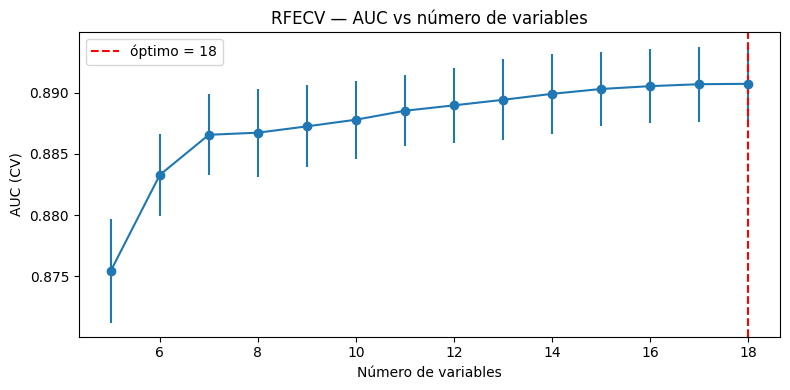

In [99]:
# %% Wrapper — RFECV (Recursive Feature Elimination con CV agrupado)
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold

tr01 = dev[dev["VarDep"].isin([0, 1])]
y_w = tr01["VarDep"].astype(int)
grupos_w = tr01["IDENTIFICACION"].to_numpy()

# RFE elimina por magnitud del coeficiente -> imputar y escalar primero
X_w = pd.DataFrame(
    StandardScaler().fit_transform(
        SimpleImputer(strategy="median").fit_transform(tr01[filtro_corr].astype(float))),
    columns=filtro_corr, index=tr01.index,
)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=13579),
    step=1,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=13579),
    scoring="roc_auc",
    min_features_to_select=5,
    n_jobs=-1,
)
rfecv.fit(X_w, y_w, groups=grupos_w)

seleccion_final = [c for c, keep in zip(filtro_corr, rfecv.support_) if keep]
print(f"RFECV — número óptimo de variables: {rfecv.n_features_}")
print(f"\nSELECCIÓN FINAL ({len(seleccion_final)}):")
for c in seleccion_final:
    print("  -", c)

# Curva: AUC (CV) vs número de variables
scores = rfecv.cv_results_["mean_test_score"]
stds = rfecv.cv_results_["std_test_score"]
xs = list(range(rfecv.min_features_to_select,
                 rfecv.min_features_to_select + len(scores)))
plt.figure(figsize=(8, 4))
plt.errorbar(xs, scores, yerr=stds, marker="o")
plt.axvline(rfecv.n_features_, color="red", ls="--",
            label=f"óptimo = {rfecv.n_features_}")
plt.xlabel("Número de variables")
plt.ylabel("AUC (CV)")
plt.title("RFECV — AUC vs número de variables")
plt.legend()
plt.tight_layout()
plt.show()

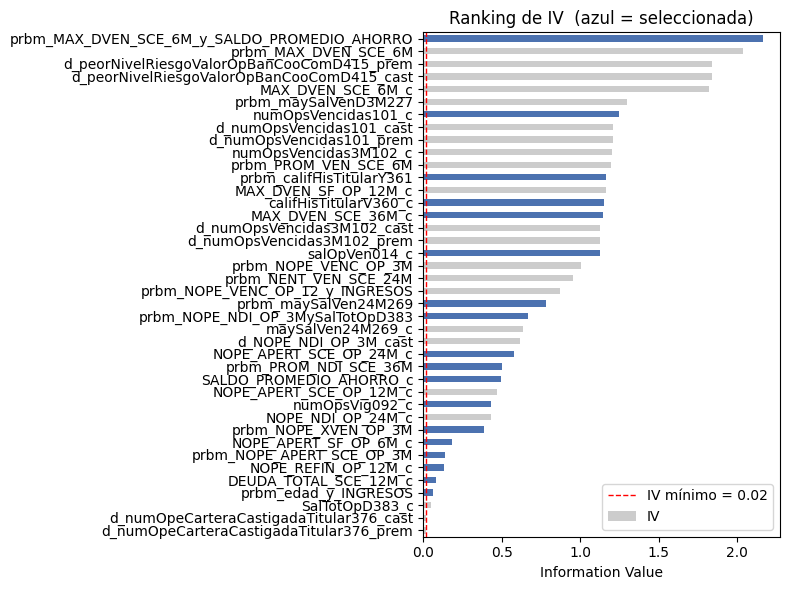

In [100]:
# %% Grafico del ranking de IV
import matplotlib.pyplot as plt

colores = ["#4c72b0" if c in seleccion_final else "#cccccc" for c in iv_tab.index]
plt.figure(figsize=(8, 6))
iv_tab[::-1].plot.barh(color=colores[::-1])
plt.axvline(IV_MIN, color="red", ls="--", lw=1, label=f"IV mínimo = {IV_MIN}")
plt.xlabel("Information Value")
plt.title("Ranking de IV  (azul = seleccionada)")
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
# %% Guardar la seleccion de variables
with open("BDD/features_seleccionadas.pkl", "wb") as f:
    pickle.dump(seleccion_final, f)
print("Selección guardada en BDD/features_seleccionadas.pkl")
for c in seleccion_final:
    print(" -", c)

Selección guardada en BDD/features_seleccionadas.pkl
 - prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO
 - numOpsVencidas101_c
 - prbm_califHisTitularY361
 - califHisTitularV360_c
 - MAX_DVEN_SCE_36M_c
 - salOpVen014_c
 - prbm_maySalVen24M269
 - prbm_NOPE_NDI_OP_3MySalTotOpD383
 - NOPE_APERT_SCE_OP_24M_c
 - prbm_PROM_NDI_SCE_36M
 - SALDO_PROMEDIO_AHORRO_c
 - numOpsVig092_c
 - prbm_NOPE_XVEN_OP_3M
 - NOPE_APERT_SF_OP_6M_c
 - prbm_NOPE_APERT_SCE_OP_3M
 - NOPE_REFIN_OP_12M_c
 - DEUDA_TOTAL_SCE_12M_c
 - prbm_edad_y_INGRESOS


# Optimización de hiperparámetros

Modelo base: **Regresión Logística Regularizada (L2)**. El hiperparámetro a optimizar
es la fuerza de regularización **λ**; en sklearn se controla con `C = 1/λ`.

- Búsqueda con **repeated stratified GROUP k-fold CV** sobre `DEV` (10 folds × 5
  repeticiones). Es *group* k-fold: agrupa por `IDENTIFICACION`, así un mismo cliente
  nunca cae a la vez en el fold de entrenamiento y en el de validación (sin fuga).
- Métrica: **AUC** (estándar en credit scoring).
- El preprocesamiento (imputación + escalado) va dentro de un `Pipeline`, así se
  ajusta **dentro de cada fold** y no hay fuga entre folds.

Entregables: gráfica de optimización de λ y curva de aprendizaje.

> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Implementa la optimización de hiperparámetros de la regresión logística
> regularizada: optimiza λ con repeated StratifiedGroupKFold y presenta la gráfica de λ y la
> curva de aprendizaje.
Además necesito que escribas en markdown esta explicacion porque hacer esto esta bien y no hace fuga y respeta los meses para los cuales los clientes aparecen"*

### ¿Qué hace `StratifiedGroupKFold`?

Es la validación cruzada del modelo, diseñada para **no tener fuga de información**.

- **Reparte por cliente, no por fila.** Cada cliente (`IDENTIFICACION`) —con todas sus
  filas— se asigna **entero a un solo fold**.
- **Hace los splits rotando.** En cada iteración un fold distinto es el de validación
  y el resto es entrenamiento. Es el mismo conjunto de clientes; lo que cambia es qué
  fold valida.
- **Sin fuga:** en cualquier iteración un cliente está 100% en entrenamiento o 100% en
  validación, nunca en ambos → el modelo no "memoriza" al cliente.
- **Stratified:** además mantiene la misma tasa de malos en cada fold.

Así el CV mide honestamente la generalización a **clientes nuevos**.

### ¿Importa la temporalidad en credit scoring?

Sí, pero **no como variable del modelo**.

- El scorecard **no lleva la fecha como predictor**: captura la relación
  *cliente → riesgo*, que se asume estable; debe servir para clientes futuros.
- La temporalidad se gestiona **alrededor**: ventanas de observación/desempeño,
  prueba `TEST_OOT`, PSI y el seguimiento de bad rate por cohorte.
- **Discriminación vs calibración:** la capacidad de ordenar el riesgo (AUC, KS) se
  mantiene en el tiempo; el **nivel** de PD sí deriva con el ciclo económico (el bad
  rate subió de 38% a 44%).
- Esa deriva del nivel **no la recoge el modelo** — se corrige **recalibrando**
  periódicamente, no metiendo el tiempo como variable.


In [102]:
# %% Datos de modelado, pipeline y CV agrupado por cliente
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedGroupKFold, validation_curve,
                                     learning_curve)

# Poblacion de modelado: DEV restringido a bueno/malo, con las features seleccionadas
mod = dev[dev["VarDep"].isin([0, 1])]
X = mod[seleccion_final].astype(float)
y = mod["VarDep"].astype(int)
groups = mod["IDENTIFICACION"].to_numpy()          # cliente -> para agrupar el CV
print("X:", X.shape, "| tasa de malos:", round(y.mean(), 4),
      "| clientes únicos:", mod["IDENTIFICACION"].nunique())

# Pipeline: imputacion -> escalado -> logistica L2
modelo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000, random_state=13579)),
])


# CV: Repeated Stratified GROUP K-Fold -> cada cliente entero en un solo fold
def cv_agrupado(X, y, groups, n_splits=10, n_repeats=5, semilla=13579):
    rng = np.random.RandomState(semilla)
    splits = []
    for _ in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                    random_state=rng.randint(1_000_000))
        splits.extend(sgkf.split(X, y, groups))
    return splits


cv = cv_agrupado(X, y, groups)
print("Folds de CV (10x5):", len(cv))

X: (31696, 18) | tasa de malos: 0.397 | clientes únicos: 31696
Folds de CV (10x5): 50


λ óptimo = 162.4   (C = 0.006158)
AUC CV óptimo = 0.8908 ± 0.0064


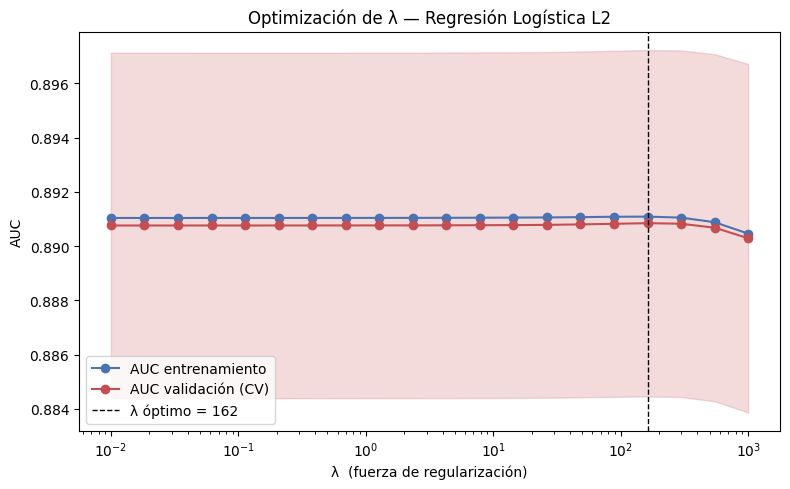

In [103]:
# %% Optimizacion de lambda (validation curve)
Cs = np.logspace(-3, 2, 20)          # C = 1/lambda
lambdas = 1 / Cs

train_sc, val_sc = validation_curve(
    modelo, X, y, param_name="logit__C", param_range=Cs,
    scoring="roc_auc", cv=cv, n_jobs=-1)

train_m, val_m = train_sc.mean(axis=1), val_sc.mean(axis=1)
val_s = val_sc.std(axis=1)

idx = val_m.argmax()
mejor_C = Cs[idx]
mejor_lambda = lambdas[idx]
print(f"λ óptimo = {mejor_lambda:.4g}   (C = {mejor_C:.4g})")
print(f"AUC CV óptimo = {val_m[idx]:.4f} ± {val_s[idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(lambdas, train_m, "o-", color="#4c72b0", label="AUC entrenamiento")
plt.plot(lambdas, val_m, "o-", color="#c44e52", label="AUC validación (CV)")
plt.fill_between(lambdas, val_m - val_s, val_m + val_s, color="#c44e52", alpha=0.2)
plt.axvline(mejor_lambda, color="black", ls="--", lw=1,
            label=f"λ óptimo = {mejor_lambda:.3g}")
plt.xscale("log")
plt.xlabel("λ  (fuerza de regularización)")
plt.ylabel("AUC")
plt.title("Optimización de λ — Regresión Logística L2")
plt.legend()
plt.tight_layout()
plt.show()

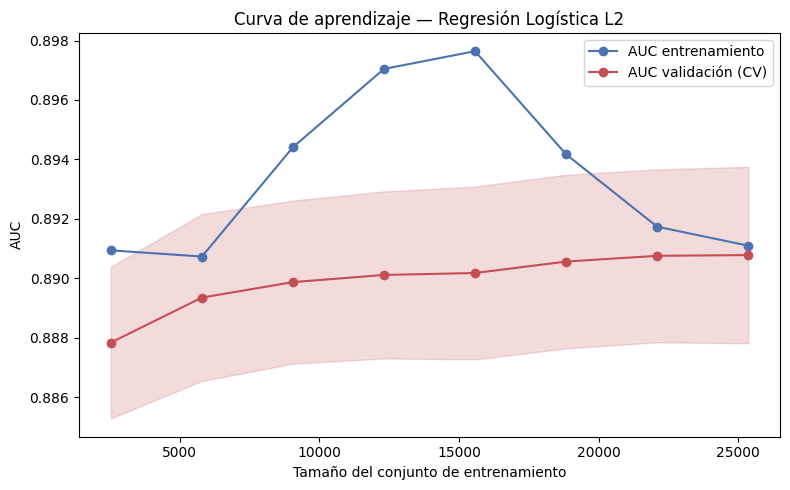

In [104]:
# %% Curva de aprendizaje (con el lambda optimo)
modelo_opt = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(C=mejor_C, max_iter=1000, random_state=13579)),
])

sizes, lc_tr, lc_val = learning_curve(
    modelo_opt, X, y, groups=groups,
    cv=StratifiedGroupKFold(5, shuffle=True, random_state=13579),
    scoring="roc_auc", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, lc_tr.mean(axis=1), "o-", color="#4c72b0", label="AUC entrenamiento")
plt.plot(sizes, lc_val.mean(axis=1), "o-", color="#c44e52", label="AUC validación (CV)")
plt.fill_between(sizes, lc_val.mean(1) - lc_val.std(1),
                 lc_val.mean(1) + lc_val.std(1), color="#c44e52", alpha=0.2)
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("AUC")
plt.title("Curva de aprendizaje — Regresión Logística L2")
plt.legend()
plt.tight_layout()
plt.show()

In [105]:
# %% Ajuste del modelo optimo
modelo_opt.fit(X, y)

print("Modelo final ajustado en DEV")
print(f"  λ óptimo  = {mejor_lambda:.4g}  (C = {mejor_C:.4g})")
print(f"  AUC CV    = {val_m[idx]:.4f} ± {val_s[idx]:.4f}")
print(f"  Variables = {len(seleccion_final)}")

Modelo final ajustado en DEV
  λ óptimo  = 162.4  (C = 0.006158)
  AUC CV    = 0.8908 ± 0.0064
  Variables = 18


In [ ]:
# %% Métricas por validación cruzada
from sklearn.model_selection import cross_validate
from scipy.stats import ks_2samp


def ks_statistic(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if y_score.ndim == 2:                 # por si llega predict_proba completo
        y_score = y_score[:, 1]
    return ks_2samp(y_score[y_true == 1], y_score[y_true == 0]).statistic


def ks_scorer(estimator, X, y):           # scorer callable: sin make_scorer
    proba = estimator.predict_proba(X)[:, 1]
    return ks_statistic(np.asarray(y), proba)


scorers = {
    "AUC": "roc_auc", "Accuracy": "accuracy", "Precision": "precision",
    "Recall": "recall", "F1": "f1",
    "KS": ks_scorer,
}
res_cv = cross_validate(modelo_opt, X, y, cv=cv, scoring=scorers, n_jobs=-1)

tabla_cv = pd.DataFrame(
    {m: [res_cv[f"test_{m}"].mean(), res_cv[f"test_{m}"].std()] for m in scorers},
    index=["media", "desv"],
).T
tabla_cv.loc["Gini"] = [2 * tabla_cv.loc["AUC", "media"] - 1, 2 * tabla_cv.loc["AUC", "desv"]]
tabla_cv.round(4)


,media,desv
AUC,0.8908,0.0064
Accuracy,0.8293,0.0063
Precision,0.8303,0.0106
Recall,0.7165,0.0118
F1,0.7692,0.0089
KS,0.6375,0.0141
Gini,0.7817,0.0128


# Comparación estadística de dos técnicas (paso 6 de la rúbrica)

Se compara el modelo base —**Regresión Logística Regularizada**— contra un
**Random Forest** (modelo no lineal de ensamble). Ambos se evalúan con **el mismo CV
agrupado por cliente** (`cv`), obteniendo el AUC en cada fold, y se contrastan con un
**test de Wilcoxon de rangos con signo** (test pareado, no asume normalidad).

- **H₀:** las dos técnicas tienen el mismo desempeño (AUC).
- **H₁:** hay diferencia.

*Nota:* con CV repetido los folds no son del todo independientes, por lo que el
p-valor es aproximado (es la práctica que pide la rúbrica).

> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Implementa la comparación estadística de dos técnicas de ML: la regresión
> logística regularizada frente a otro modelo, con un test de hipótesis
> (Wilcoxon / t-test) sobre repeated k-fold CV."*

In [107]:
# %% Comparacion: Logistica L2 vs Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy.stats import wilcoxon

# Modelo A: regresion logistica regularizada (el optimo del paso 5)
modelo_A = modelo_opt

# Modelo B: Random Forest (no necesita escalado; si imputacion)
modelo_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(n_estimators=300, max_depth=6,
                                  random_state=13579, n_jobs=-1)),
])

# AUC por fold, con LOS MISMOS folds agrupados por cliente
auc_A = cross_val_score(modelo_A, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
auc_B = cross_val_score(modelo_B, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Logística L2 : AUC = {auc_A.mean():.4f} ± {auc_A.std():.4f}")
print(f"Random Forest: AUC = {auc_B.mean():.4f} ± {auc_B.std():.4f}")

Logística L2 : AUC = 0.8908 ± 0.0064
Random Forest: AUC = 0.8947 ± 0.0060


Wilcoxon: estadístico = 23.0,  p-valor = 1.137e-12
p < 0.05  ->  diferencia SIGNIFICATIVA. Mejor desempeño: Random Forest


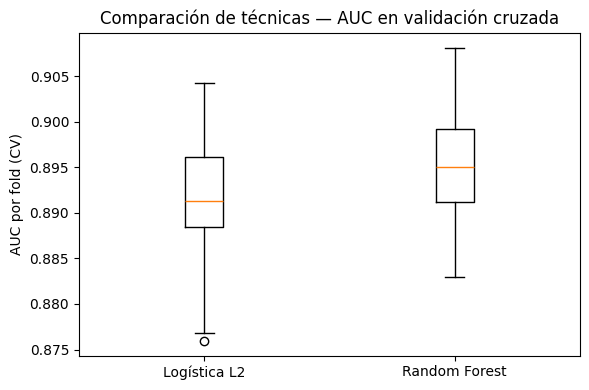

In [108]:
# %% Test de hipotesis pareado (Wilcoxon)
stat, p = wilcoxon(auc_A, auc_B)
print(f"Wilcoxon: estadístico = {stat:.1f},  p-valor = {p:.4g}")

alpha = 0.05
if p < alpha:
    mejor = "Logística L2" if auc_A.mean() > auc_B.mean() else "Random Forest"
    print(f"p < {alpha}  ->  diferencia SIGNIFICATIVA. Mejor desempeño: {mejor}")
else:
    print(f"p >= {alpha}  ->  NO hay diferencia significativa entre las dos técnicas")

plt.figure(figsize=(6, 4))
plt.boxplot([auc_A, auc_B])
plt.xticks([1, 2], ["Logística L2", "Random Forest"])
plt.ylabel("AUC por fold (CV)")
plt.title("Comparación de técnicas — AUC en validación cruzada")
plt.tight_layout()
plt.show()

# Pipelines de sklearn (paso 7 de la rúbrica)

Todo el flujo se integra en un único `Pipeline`: **filtro de feature selection +
preprocesamiento + modelo**. Así cada paso se reajusta **dentro de cada fold** de la
validación cruzada y se evita la fuga de datos.

El filtro de feature selection (Information Value) se implementa como un
**transformer propio** (`FiltroIV`), compatible con la API de sklearn — es la versión
"productizada" del filtro del paso 4.

> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Integra todo el flujo en un Pipeline de sklearn, incluyendo el filtro de feature
> selection como un transformer propio."*

In [109]:
# %% Transformer propio: filtro tipo filter por Information Value
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score


class FiltroIV(BaseEstimator, TransformerMixin):
    """Feature selection tipo filter: conserva las columnas con IV >= umbral.
    El IV se calcula en fit (solo con el train del fold) -> sin fuga."""

    def __init__(self, umbral=0.02, bins=10):
        self.umbral = umbral
        self.bins = bins

    @staticmethod
    def _iv(x, y, bins):
        d = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(y)})
        if d["x"].nunique(dropna=True) <= 10:
            d["g"] = d["x"]
        else:
            d["g"] = pd.qcut(d["x"], bins, duplicates="drop")
        g = d.groupby("g", observed=True)["y"].agg(["count", "sum"])
        malos = g["sum"]
        buenos = g["count"] - malos
        pm = malos / malos.sum()
        pb = buenos / buenos.sum()
        eps = 1e-6
        return float(((pb - pm) * np.log((pb + eps) / (pm + eps))).sum())

    def fit(self, X, y):
        X = pd.DataFrame(X)
        self.iv_ = {c: self._iv(X[c], y, self.bins) for c in X.columns}
        self.seleccion_ = [c for c, v in self.iv_.items() if v >= self.umbral]
        return self

    def transform(self, X):
        return pd.DataFrame(X)[self.seleccion_]

In [110]:
# %% Pipeline completo: filtro IV -> imputacion -> escalado -> logistica
pipe_final = Pipeline([
    ("filtro_iv", FiltroIV(umbral=0.02)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(C=mejor_C, max_iter=1000, random_state=13579)),
])

# Se parte de TODAS las candidatas: el filtro se aplica dentro del pipeline
X_full = mod[candidatas].astype(float)

auc_pipe = cross_val_score(pipe_final, X_full, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"Pipeline completo — AUC CV = {auc_pipe.mean():.4f} ± {auc_pipe.std():.4f}")

pipe_final.fit(X_full, y)
sel = pipe_final.named_steps["filtro_iv"].seleccion_
print(f"Variables que pasaron el filtro IV dentro del pipeline: {len(sel)}")
print(sel)

Pipeline completo — AUC CV = 0.8972 ± 0.0061
Variables que pasaron el filtro IV dentro del pipeline: 38
['prbm_MAX_DVEN_SCE_6M', 'prbm_MAX_DVEN_SCE_6M_y_SALDO_PROMEDIO_AHORRO', 'prbm_NENT_VEN_SCE_24M', 'prbm_NOPE_APERT_SCE_OP_3M', 'prbm_NOPE_NDI_OP_3MySalTotOpD383', 'prbm_NOPE_VENC_OP_12_y_INGRESOS', 'prbm_NOPE_VENC_OP_3M', 'prbm_NOPE_XVEN_OP_3M', 'prbm_PROM_NDI_SCE_36M', 'prbm_PROM_VEN_SCE_6M', 'prbm_califHisTitularY361', 'prbm_edad_y_INGRESOS', 'prbm_maySalVen24M269', 'prbm_maySalVenD3M227', 'd_NOPE_NDI_OP_3M_cast', 'd_numOpsVencidas101_cast', 'd_numOpsVencidas101_prem', 'd_numOpsVencidas3M102_cast', 'd_numOpsVencidas3M102_prem', 'd_peorNivelRiesgoValorOpBanCooComD415_cast', 'd_peorNivelRiesgoValorOpBanCooComD415_prem', 'DEUDA_TOTAL_SCE_12M_c', 'MAX_DVEN_SCE_36M_c', 'MAX_DVEN_SCE_6M_c', 'MAX_DVEN_SF_OP_12M_c', 'NOPE_APERT_SCE_OP_12M_c', 'NOPE_APERT_SCE_OP_24M_c', 'NOPE_APERT_SF_OP_6M_c', 'NOPE_NDI_OP_24M_c', 'NOPE_REFIN_OP_12M_c', 'SALDO_PROMEDIO_AHORRO_c', 'SalTotOpD383_c', 'califHi

# Visualización con t-SNE 

t-SNE proyecta el espacio de características (las variables seleccionadas) a **2
dimensiones**, conservando la estructura local. Cada punto se colorea por su clase
(bueno / malo) para ver si las clases forman regiones separables.

Como t-SNE es costoso, se usa una **muestra aleatoria** de la población de modelado.

> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Añade una visualización con t-SNE del espacio de características, coloreando cada
> punto por su clase (bueno / malo)."*

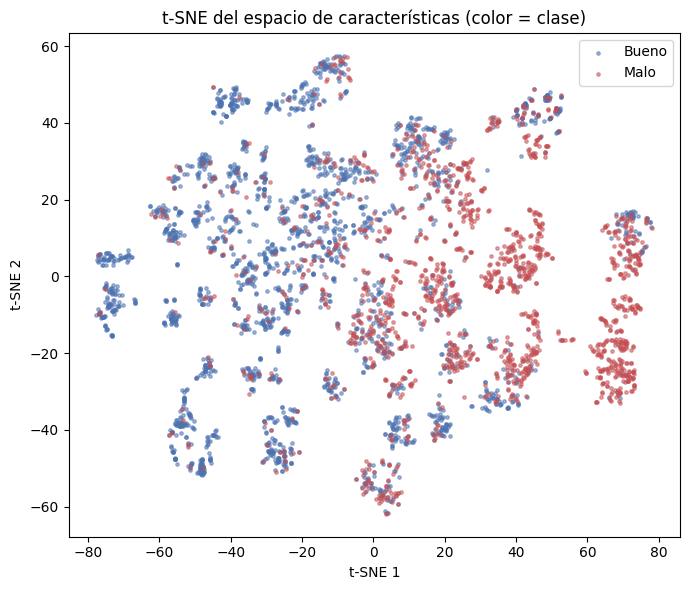

In [111]:
# %% t-SNE del espacio de caracteristicas
from sklearn.manifold import TSNE

# muestra para que t-SNE sea manejable
n_muestra = 4000
rng = np.random.RandomState(13579)
idx = rng.choice(len(X), size=min(n_muestra, len(X)), replace=False)
X_s, y_s = X.iloc[idx], y.iloc[idx]

# imputar + escalar antes de proyectar
X_prep = StandardScaler().fit_transform(
    SimpleImputer(strategy="median").fit_transform(X_s))

emb = TSNE(n_components=2, perplexity=30, init="pca",
           random_state=13579).fit_transform(X_prep)

plt.figure(figsize=(7, 6))
for clase, color, lab in [(0, "#4c72b0", "Bueno"), (1, "#c44e52", "Malo")]:
    m = y_s.to_numpy() == clase
    plt.scatter(emb[m, 0], emb[m, 1], s=6, c=color, alpha=0.5, label=lab)
plt.legend()
plt.title("t-SNE del espacio de características (color = clase)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# Evaluación del modelo — Performance y Test OOT

Cierre del proyecto: se mide el modelo final con la **tabla de performance** del
scorecard y, sobre todo, se evalúa en el conjunto **`TEST_OOT`** (cohorte 2022-09),
nunca visto durante el desarrollo.

> ### 🤖 Asistencia de IA — *prompt del paso*
> *"Faltó testear el modelo. Implementa la evaluación final: tabla de performance,
> aplicación al `TEST_OOT`, comparación de métricas DEV vs OOT, curvas ROC y KS,
> tabla de performance en OOT y el PSI del score."*

## Evaluación en TEST_OOT (out-of-time)

`TEST_OOT` es la cohorte 2022-09, **reservada y nunca usada** en el desarrollo. Se le
aplican las **mismas reglas** de binning (ajustadas en DEV) y el modelo final, y se
compara su desempeño con el de DEV. Una caída pequeña confirma que el modelo es
**estable fuera de tiempo**; una caída grande indicaría sobreajuste o *drift*.

In [112]:
# %% Preparar el TEST_OOT — binning con las reglas YA ajustadas en DEV
with open("BDD/reglas_binning.pkl", "rb") as f:
    reglas = pickle.load(f)

test = info[info["MUESTRA"] == "TEST_OOT"].copy()
test = construir_features(test)

test01 = test[test["VarDep"].isin([0, 1])]
X_test = test01[seleccion_final].astype(float)
y_test = test01["VarDep"].astype(int)
print("TEST_OOT (VarDep 0/1):", X_test.shape,
      "| tasa de malos:", round(y_test.mean(), 4))

TEST_OOT (VarDep 0/1): (9697, 18) | tasa de malos: 0.4438


In [113]:
# %% Métricas: DEV (validación cruzada) vs TEST_OOT
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score)


def metricas(modelo, X, y, umbral=0.5):
    y = np.asarray(y).astype(int)
    proba = modelo.predict_proba(X)[:, 1]
    pred = (proba >= umbral).astype(int)
    a = roc_auc_score(y, proba)
    return pd.Series({
        "AUC": a, "Gini": 2 * a - 1, "KS": ks_statistic(y, proba),
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
    })


comparacion = pd.DataFrame({
    "DEV (CV)": tabla_cv["media"],
    "TEST_OOT": metricas(modelo_opt, X_test, y_test),
})
comparacion["Δ (OOT − DEV)"] = comparacion["TEST_OOT"] - comparacion["DEV (CV)"]
comparacion.round(4)

,DEV (CV),TEST_OOT,Δ (OOT − DEV)
AUC,0.8908,0.8887,-0.0021
Accuracy,0.8293,0.8106,-0.0187
F1,0.7692,0.7682,-0.0010
Gini,0.7817,0.7775,-0.0042
KS,0.6375,0.6205,-0.0169
Precision,0.8303,0.8407,0.0104
Recall,0.7165,0.7072,-0.0093


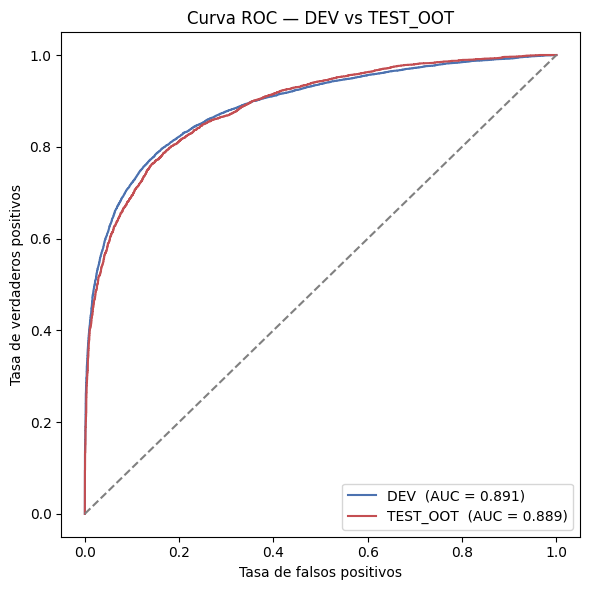

In [114]:
# Curva ROC — DEV vs TEST_OOT
from sklearn.metrics import roc_curve, auc as _auc

proba_dev = modelo_opt.predict_proba(X)[:, 1]
proba_oot = modelo_opt.predict_proba(X_test)[:, 1]

fpr_d, tpr_d, _ = roc_curve(y, proba_dev)
fpr_o, tpr_o, _ = roc_curve(y_test, proba_oot)

plt.figure(figsize=(6, 6))
plt.plot(fpr_d, tpr_d, color="#4c72b0", label=f"DEV  (AUC = {_auc(fpr_d, tpr_d):.3f})")
plt.plot(fpr_o, tpr_o, color="#c44e52",
         label=f"TEST_OOT  (AUC = {_auc(fpr_o, tpr_o):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — DEV vs TEST_OOT")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

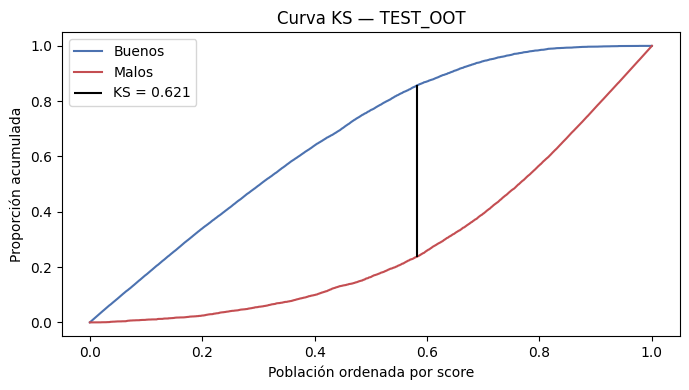

In [115]:
# Curva KS — TEST_OOT
orden = np.argsort(proba_oot)
yb = (y_test.to_numpy()[orden] == 0)
ym = (y_test.to_numpy()[orden] == 1)
cum_b = np.cumsum(yb) / yb.sum()
cum_m = np.cumsum(ym) / ym.sum()
dif = np.abs(cum_m - cum_b)
ks_i = int(dif.argmax())

eje = np.arange(1, len(proba_oot) + 1) / len(proba_oot)
plt.figure(figsize=(7, 4))
plt.plot(eje, cum_b, color="#4c72b0", label="Buenos")
plt.plot(eje, cum_m, color="#c44e52", label="Malos")
plt.vlines(eje[ks_i], cum_b[ks_i], cum_m[ks_i], color="black",
           label=f"KS = {dif[ks_i]:.3f}")
plt.xlabel("Población ordenada por score")
plt.ylabel("Proporción acumulada")
plt.title("Curva KS — TEST_OOT")
plt.legend()
plt.tight_layout()
plt.show()

## Tablas de performance del scorecard — DEV vs TEST_OOT

Las bandas de score (deciles) se **derivan una sola vez en `DEV`** y esos **mismos
cortes** se aplican a `TEST_OOT` — como en un scorecard real, donde los grados son
fijos. Un buen modelo **rank-ordena** (tasa de malos monótona, verde → rojo); además,
en `TEST_OOT` el `pct_poblacion` deja de ser 10% por banda: esa desviación es la señal
de *drift* (coherente con el PSI del score).

In [116]:
# %% Tabla de performance del scorecard — los cortes se derivan en DEV
def tabla_performance(modelo, X, y, n_bandas=10, cortes=None):
    proba = modelo.predict_proba(X)[:, 1]            # P(malo)
    score = (1 - proba) * 1000                       # score: mayor = menor riesgo
    df = pd.DataFrame({"score": score, "y": np.asarray(y).astype(int)})

    if cortes is None:                               # DEV: se derivan los cortes
        _, cortes = pd.qcut(df["score"], n_bandas, retbins=True, duplicates="drop")
        cortes = np.array(cortes, dtype=float)
        cortes[0], cortes[-1] = -np.inf, np.inf      # cubrir los extremos de TEST

    # los MISMOS cortes se aplican siempre (en DEV y en TEST)
    df["banda"] = pd.cut(df["score"], bins=cortes,
                         labels=range(1, len(cortes)), include_lowest=True)

    t = df.groupby("banda", observed=True).agg(
        score_min=("score", "min"),
        score_max=("score", "max"),
        N=("y", "size"),
        malos=("y", "sum"),
    ).sort_index()
    t["buenos"] = t["N"] - t["malos"]
    t["tasa_malos"] = t["malos"] / t["N"]
    t["pct_poblacion"] = t["N"] / t["N"].sum()
    t["malos_acum_%"] = t["malos"].cumsum() / t["malos"].sum()
    t["buenos_acum_%"] = t["buenos"].cumsum() / t["buenos"].sum()
    t["KS"] = (t["malos_acum_%"] - t["buenos_acum_%"]).abs()
    cols = ["score_min", "score_max", "N", "pct_poblacion", "buenos", "malos",
            "tasa_malos", "malos_acum_%", "buenos_acum_%", "KS"]
    return t[cols], cortes


# DEV: deriva y guarda los cortes del scorecard
perf, cortes_dev = tabla_performance(modelo_opt, X, y, n_bandas=10)

print("Rank-ordering en DEV:", perf["tasa_malos"].is_monotonic_decreasing)
print("KS del scorecard en DEV:", round(perf["KS"].max(), 4))

(perf.style
     .background_gradient(subset=["tasa_malos"], cmap="RdYlGn_r")
     .format({"score_min": "{:.0f}", "score_max": "{:.0f}", "N": "{:,.0f}",
              "pct_poblacion": "{:.1%}", "buenos": "{:,.0f}", "malos": "{:,.0f}",
              "tasa_malos": "{:.2%}", "malos_acum_%": "{:.1%}",
              "buenos_acum_%": "{:.1%}", "KS": "{:.3f}"})
     .set_caption("DEV — banda 1 = menor score (mayor riesgo) · banda 10 = mayor "
                  "score (menor riesgo). Color = tasa de malos (verde→rojo)."))

Rank-ordering en DEV: True
KS del scorecard en DEV: 0.6331


,score_min,score_max,N,pct_poblacion,buenos,malos,tasa_malos,malos_acum_%,buenos_acum_%,KS
banda,,,,,,,,,,
1,0,40,"3,170",10.0%,35,"3,135",98.90%,24.9%,0.2%,0.247
2,40,181,"3,170",10.0%,291,"2,879",90.82%,47.8%,1.7%,0.461
3,181,397,"3,169",10.0%,893,"2,276",71.82%,65.9%,6.4%,0.595
4,397,633,"3,170",10.0%,"1,623","1,547",48.80%,78.2%,14.9%,0.633
5,633,773,"3,169",10.0%,"2,182",987,31.15%,86.0%,26.3%,0.597
6,773,837,"3,170",10.0%,"2,547",623,19.65%,91.0%,39.6%,0.514
7,837,873,"3,169",10.0%,"2,728",441,13.92%,94.5%,53.9%,0.406
8,873,899,"3,170",10.0%,"2,850",320,10.09%,97.0%,68.8%,0.282
9,899,923,"3,169",10.0%,"2,942",227,7.16%,98.8%,84.2%,0.146


In [117]:
# %% Tabla de performance — TEST_OOT (con los MISMOS cortes de DEV)
perf_oot, _ = tabla_performance(modelo_opt, X_test, y_test, cortes=cortes_dev)

print("Rank-ordering en TEST_OOT:", perf_oot["tasa_malos"].is_monotonic_decreasing)
print("KS del scorecard en TEST_OOT:", round(perf_oot["KS"].max(), 4))

(perf_oot.style
     .background_gradient(subset=["tasa_malos"], cmap="RdYlGn_r")
     .format({"score_min": "{:.0f}", "score_max": "{:.0f}", "N": "{:,.0f}",
              "pct_poblacion": "{:.1%}", "buenos": "{:,.0f}", "malos": "{:,.0f}",
              "tasa_malos": "{:.2%}", "malos_acum_%": "{:.1%}",
              "buenos_acum_%": "{:.1%}", "KS": "{:.3f}"})
     .set_caption("TEST_OOT con los cortes de DEV — pct_poblacion distinto de 10% "
                  "revela el drift; la tasa de malos debe seguir rank-ordenando."))

Rank-ordering en TEST_OOT: True
KS del scorecard en TEST_OOT: 0.6177


,score_min,score_max,N,pct_poblacion,buenos,malos,tasa_malos,malos_acum_%,buenos_acum_%,KS
banda,,,,,,,,,,
1,0,40,"1,129",11.6%,18,"1,111",98.41%,25.8%,0.3%,0.255
2,40,181,"1,046",10.8%,102,944,90.25%,47.7%,2.2%,0.455
3,181,397,"1,030",10.6%,283,747,72.52%,65.1%,7.5%,0.576
4,397,633,991,10.2%,452,539,54.39%,77.6%,15.9%,0.618
5,634,773,"1,108",11.4%,724,384,34.66%,86.5%,29.3%,0.573
6,773,837,"1,064",11.0%,795,269,25.28%,92.8%,44.0%,0.488
7,837,873,927,9.6%,788,139,14.99%,96.0%,58.6%,0.374
8,873,899,844,8.7%,750,94,11.14%,98.2%,72.5%,0.257
9,899,923,825,8.5%,778,47,5.70%,99.3%,87.0%,0.123


In [118]:
# %% PSI del score entre DEV y TEST_OOT
psi_score = psi(proba_dev, proba_oot)
print(f"PSI del score (DEV vs TEST_OOT): {psi_score:.4f}")
print("Interpretación:  < 0.10 estable  ·  0.10-0.25 cambio moderado  ·  > 0.25 fuerte")

PSI del score (DEV vs TEST_OOT): 0.0176
Interpretación:  < 0.10 estable  ·  0.10-0.25 cambio moderado  ·  > 0.25 fuerte


# Conclusiones

- **Modelo.** Se construyó un scorecard con **regresión logística regularizada (L2)**
  sobre **18 variables**, seleccionadas con un esquema **híbrido**: filtro por
  Information Value + correlación y refinamiento *wrapper* con RFECV. Toda la
  estimación (binning, selección, hiperparámetros) se hizo solo en `DEV`, con
  validación cruzada **agrupada por cliente** para evitar fuga de datos.
- **Hiperparámetro.** El λ óptimo es **162,4** (`C` ≈ 0,0062) — una regularización
  fuerte: el modelo penaliza bastante los coeficientes, lo que sugiere
  multicolinealidad residual entre predictores; aun así generaliza bien.
- **Desempeño (validación cruzada).** **AUC 0,891 · Gini 0,782 · KS 0,637**, con
  Accuracy 0,83, Recall 0,72 y Precision 0,83. Para credit scoring son cifras **muy
  buenas** (KS > 0,5 y Gini > 0,6 se consideran un modelo fuerte).
- **Comparación de técnicas.** Random Forest obtuvo AUC 0,8947 frente a 0,8908 de la
  logística; el test de **Wilcoxon (p ≈ 1,1 × 10⁻¹²)** marca la diferencia como
  *estadísticamente significativa*, pero su **magnitud es mínima (+0,004 de AUC)**.
  En riesgo de crédito se prefiere la **logística** por su **interpretabilidad** y
  trazabilidad regulatoria.
- **Validación out-of-time.** En `TEST_OOT` (cohorte 2022-09, nunca vista) el modelo
  **mantiene el desempeño**: AUC 0,889 (vs 0,891 en CV), Gini 0,777, KS 0,621 —
  caídas mínimas (ΔAUC ≈ −0,002). La tabla de performance **sigue rank-ordenando** y
  el **PSI del score es 0,018** (< 0,10) → el modelo es **estable fuera de tiempo**.
- **Punto a vigilar.** Varias variables tienen IV > 0,5 (hasta ≈ 2); el escaneo de
  cobertura halló 713 variables crudas con IV ≥ 0,10, casi todas de mora de buró. IV
  tan altos pueden indicar predictores casi deterministas → conviene confirmar que la
  mora del buró es estrictamente **previa** al punto de observación.


# Referencias


[1] N. Siddiqi, *Intelligent Credit Scoring: Building and Implementing Better Credit
Risk Scorecards*, 2nd ed. Hoboken, NJ, USA: Wiley, 2017.


[2] L. van der Maaten and G. Hinton, "Visualizing data using t-SNE," *Journal of
Machine Learning Research*, vol. 9, pp. 2579–2605, 2008.
https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

[3] T. Fawcett, "An introduction to ROC analysis," *Pattern Recognition Letters*,
vol. 27, no. 8, pp. 861–874, 2006.
https://people.inf.elte.hu/kiss/13dwhdm/roc.pdf

[4] F. Wilcoxon, "Individual comparisons by ranking methods," *Biometrics Bulletin*,
vol. 1, no. 6, pp. 80–83, 1945.
https://sci2s.ugr.es/keel/pdf/algorithm/articulo/wilcoxon1945.pdf

*Nota:* las consultas de asistencia de IA empleadas en cada paso están documentadas
en las celdas marcadas con 🤖 a lo largo del notebook.

In [119]:
# %% PD promedio vs bad rate, mes a mes — TRAIN (DEV) y TEST (OOT)
from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold

# --- TRAIN (DEV): PD out-of-fold para que la calibración sea honesta ---
cv_simple = StratifiedGroupKFold(5, shuffle=True, random_state=13579)
pd_dev = cross_val_predict(modelo_opt, X, y, cv=cv_simple, groups=groups,
                           method="predict_proba")[:, 1]

dev_eval = pd.DataFrame({
    "FECHA_CORTE": mod["FECHA_CORTE"].to_numpy(),
    "VarDep": y.to_numpy(),
    "PD": pd_dev,
    "muestra": "TRAIN (DEV)",
})

# --- TEST_OOT: PD del modelo final (fuera de muestra) ---
test_eval = pd.DataFrame({
    "FECHA_CORTE": test01["FECHA_CORTE"].to_numpy(),
    "VarDep": y_test.to_numpy(),
    "PD": modelo_opt.predict_proba(X_test)[:, 1],
    "muestra": "TEST_OOT",
})

ev = pd.concat([dev_eval, test_eval], ignore_index=True)

# --- Agregación mes a mes ---
mes = (ev.groupby("FECHA_CORTE")
         .agg(muestra=("muestra", "first"),
              N=("VarDep", "size"),
              PD_promedio=("PD", "mean"),
              bad_rate=("VarDep", "mean"))
         .reset_index()
         .sort_values("FECHA_CORTE"))
mes["dif (PD - bad)"] = (mes["PD_promedio"] - mes["bad_rate"])
mes.round(4)


/var/folders/v6/d_4300n96432y2g47c2hlw640000gn/T/ipykernel_1721/3336605413.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  mes.round(4)


,FECHA_CORTE,muestra,N,PD_promedio,bad_rate,dif (PD - bad)
0,2021-09-30,TRAIN (DEV),7334,0.3881,0.3825,0.0056
1,2021-12-31,TRAIN (DEV),7549,0.3853,0.3767,0.0086
2,2022-03-31,TRAIN (DEV),8055,0.3978,0.3993,-0.0015
3,2022-06-30,TRAIN (DEV),8758,0.4136,0.4244,-0.0108
4,2022-09-30,TEST_OOT,9697,0.4264,0.4438,-0.0175


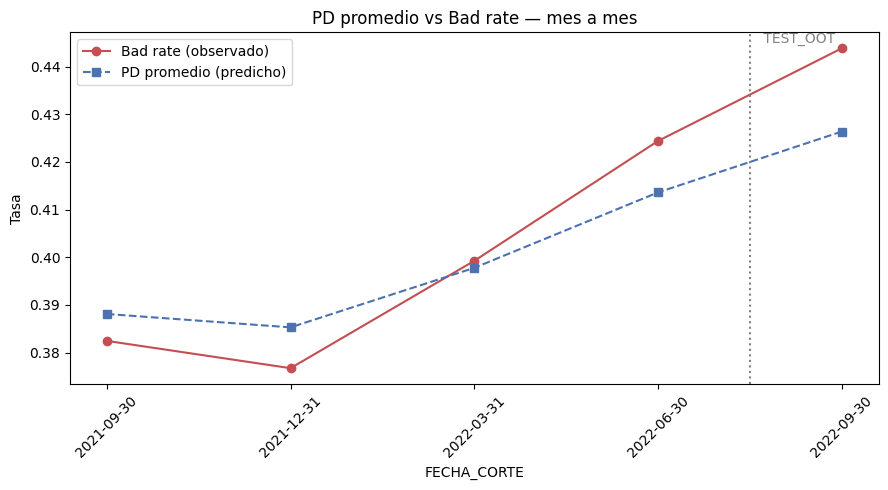

In [120]:
# %% Gráfico: PD promedio vs bad rate mes a mes
mp = mes.copy()
mp["FECHA"] = mp["FECHA_CORTE"].astype(str)
n_train = int((mp["muestra"] == "TRAIN (DEV)").sum())

plt.figure(figsize=(9, 5))
plt.plot(mp["FECHA"], mp["bad_rate"], "o-", color="#c44e52",
         label="Bad rate (observado)")
plt.plot(mp["FECHA"], mp["PD_promedio"], "s--", color="#4c72b0",
         label="PD promedio (predicho)")
if n_train < len(mp):                       # frontera TRAIN | TEST_OOT
    plt.axvline(n_train - 0.5, color="gray", ls=":", lw=1.5)
    plt.text(n_train - 0.45, plt.ylim()[1], " TEST_OOT", va="top", color="gray")
plt.ylabel("Tasa")
plt.xlabel("FECHA_CORTE")
plt.title("PD promedio vs Bad rate — mes a mes")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

